In [2]:
source("preparar_dataframes.r")
source("src/sstvars_wrapper.r")


[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘sstvars’


The following object is masked from ‘package:tsDyn’:

    GIRF




# Recorto el dataframe para 1950 a 1974

In [3]:
df_ERPT_Arg_1950_74 <- df_ERPT_Arg[1:99, ]
rownames(df_ERPT_Arg_1950_74) <- NULL
print(df_ERPT_Arg_1950_74)
tail(df_ERPT_Arg_1950_74)

    año trimestre           ipc             E           Ebc         pbird
1  1950      2ºTr  0.0710476068  0.000000e+00  0.000000e+00 -0.0164445777
2  1950      3ºTr  0.0485426448  1.822569e-01  1.822569e-01  0.0376749288
3  1950      4ºTr  0.0686389229  2.596392e-01  2.596392e-01 -0.0129753136
4  1951      1ºTr  0.0228032118  1.405321e-03  1.405321e-03  0.0271279177
5  1951      2ºTr  0.1578569708  4.855918e-03  4.855918e-03  0.0120849848
6  1951      3ºTr  0.1057701537  6.299697e-03  6.299697e-03 -0.0062139270
7  1951      4ºTr  0.0767790005  1.347034e-02  1.347034e-02 -0.0043864484
8  1952      1ºTr  0.1087066196 -1.618821e-02 -1.618821e-02  0.0024196794
9  1952      2ºTr  0.0994670088 -1.171674e-02 -1.171674e-02 -0.0324056598
10 1952      3ºTr -0.0146396976 -2.180054e-03 -2.180054e-03 -0.0513198674
11 1952      4ºTr  0.0335589046 -1.192593e-05 -1.192593e-05  0.0088992684
12 1953      1ºTr  0.0266918756 -4.770412e-06 -4.770412e-06  0.0265101685
13 1953      2ºTr -0.0389677282  0.000

,año,trimestre,ipc,E,Ebc,pbird,impp_usa,Psoja_USA,Pmaíz_USA,Ptrigo_USA,TOTfmi
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
94,1973,3ºTr,-0.001657274,0,0,0.0139439972,0.03614851,-0.12740517,0.31227751,0.5392441,NA
95,1973,4ºTr,0.053587451,0,0,0.0370107383,0.08612341,-0.26908761,-0.01764752,0.1343976,NA
96,1974,1ºTr,0.009420312,0,0,0.0147827587,0.14855104,0.08630061,0.17512460,0.1778926,NA
97,1974,2ºTr,0.075753666,0,0,0.0081844708,0.13136480,-0.14460606,-0.07765867,-0.3538707,NA
98,1974,3ºTr,0.081590922,0,0,0.0008571713,0.06551261,0.30337495,0.25415173,0.1294581,NA
99,1974,4ºTr,0.133766571,0,0,0.0112117424,0.03400403,0.07614865,0.04689952,0.1314459,NA


## Ejemplo TVAR (threshold)

Using 6 cores for 500 estimations rounds...

PHASE 1: Estimating all the parameters with a genetic algorithm...

Results from the genetic algorithm:

The lowest loglik:  535.662

The largest loglik: 599.938

PHASE 2: Estimating all the parameters with a variable metric algorithm...

Results from the variable metric algorithm:

The lowest loglik:  535.662

The largest loglik: 599.938

Filtering inappropriate estimates...

No 'appropriate'estimates found! Check that all the variables are scaled to vary in similar magninutes, also not very small or large magnitudes.

Consider running more estimation rounds or study the obtained estimates one-by-one with the function alt_stvar.

Calculating approximate standard errors...

Warning message in warn_eigens(ret, allow_unstab = allow_unstab):
“Regimes 1 and 2 have near-singular error term covariance matrices! Consider building a model from the next-largest local maximum with the function 'alt_stvar' by adjusting its argument 'which_largest' (or 

========= Unstructured fitted model ==========


Calculating approximate standard errors...



========= Structured fitted model (heteroskedasticity) ==========
Saving trained models to models/ folder

 >>> TESTS
PARA CORRER LOS TESTS CORRER LA SIGUIENTE FUNCION:
run_tests_sstvar(res, c(' ipc '), TRUE , NULL , 1 , 500 )

 >>> DIAGNOSTIC PLOTS


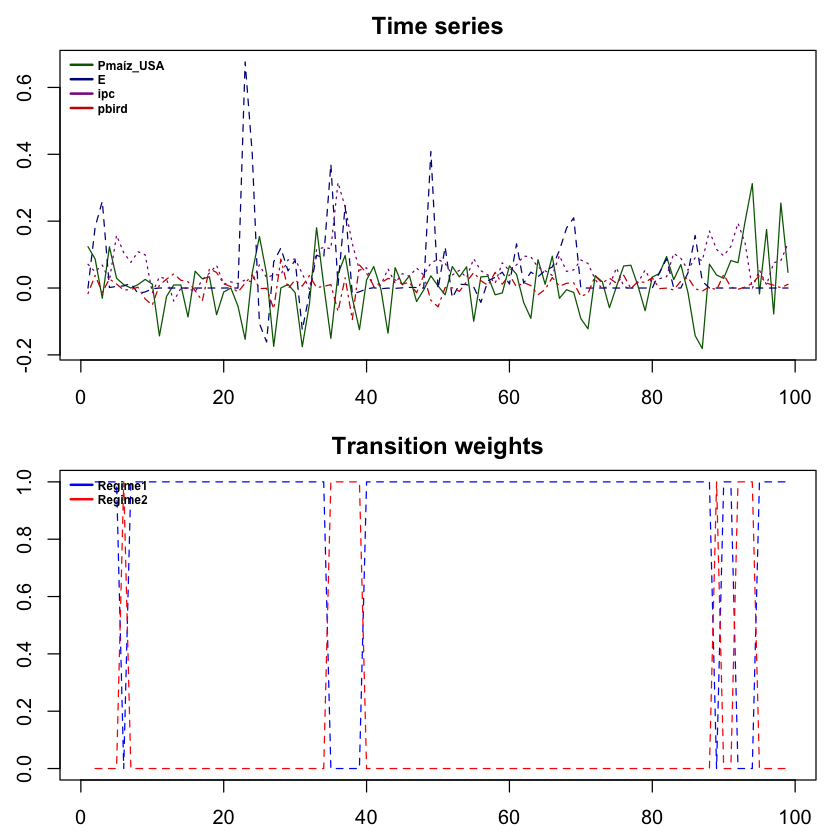

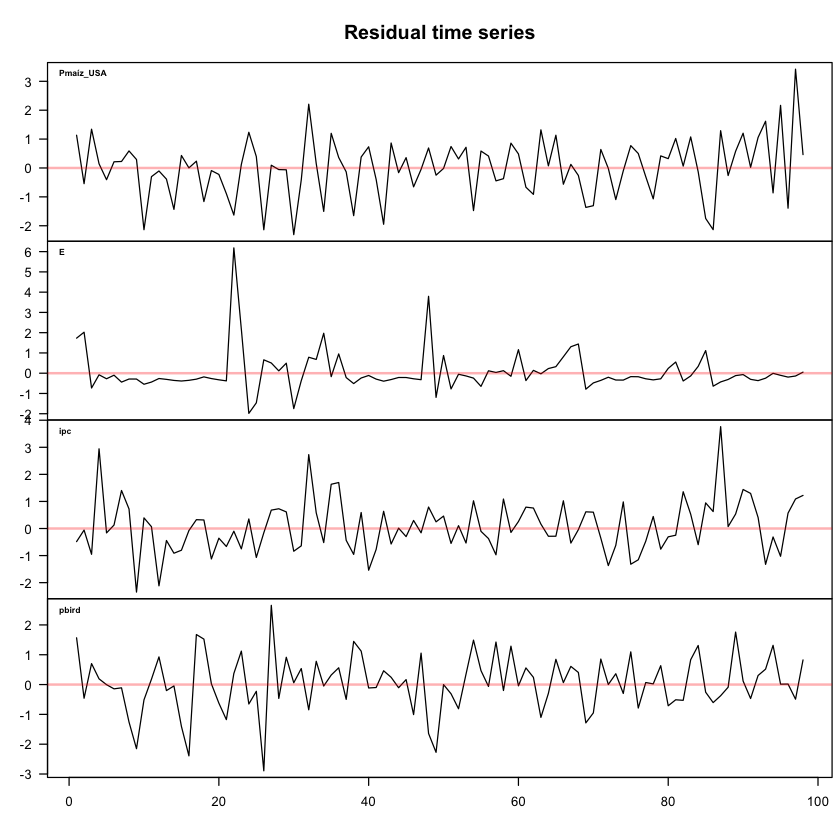

+++++++++ RÉGIMEN  1 +++++++++
 >>> GIRF ( 1  shock units)


Using 6 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



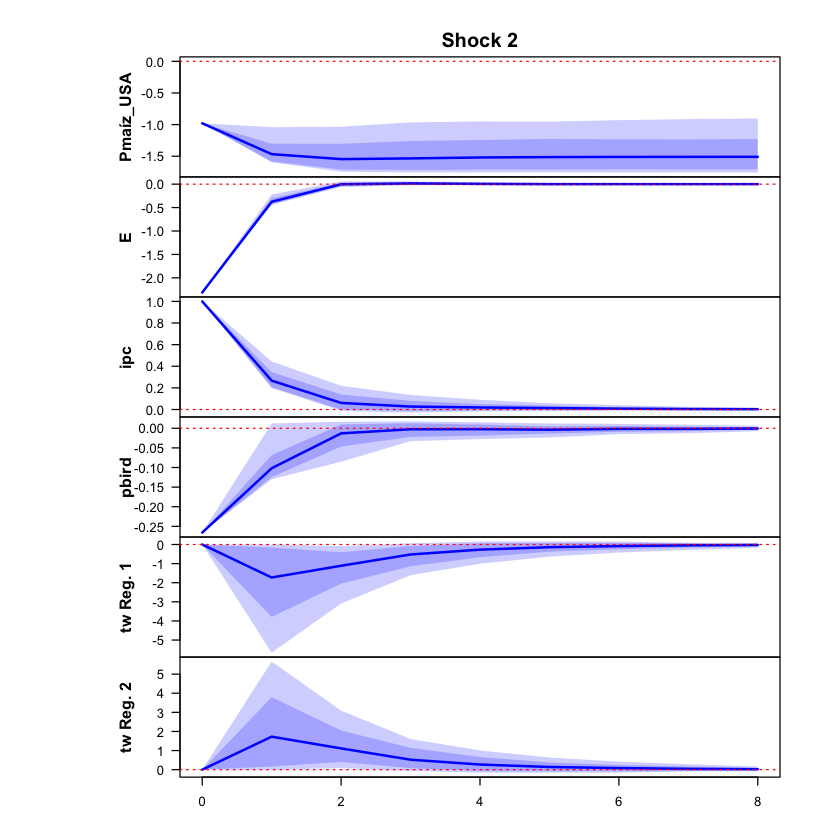

 >>> Linear IRF ( 1  shock units)


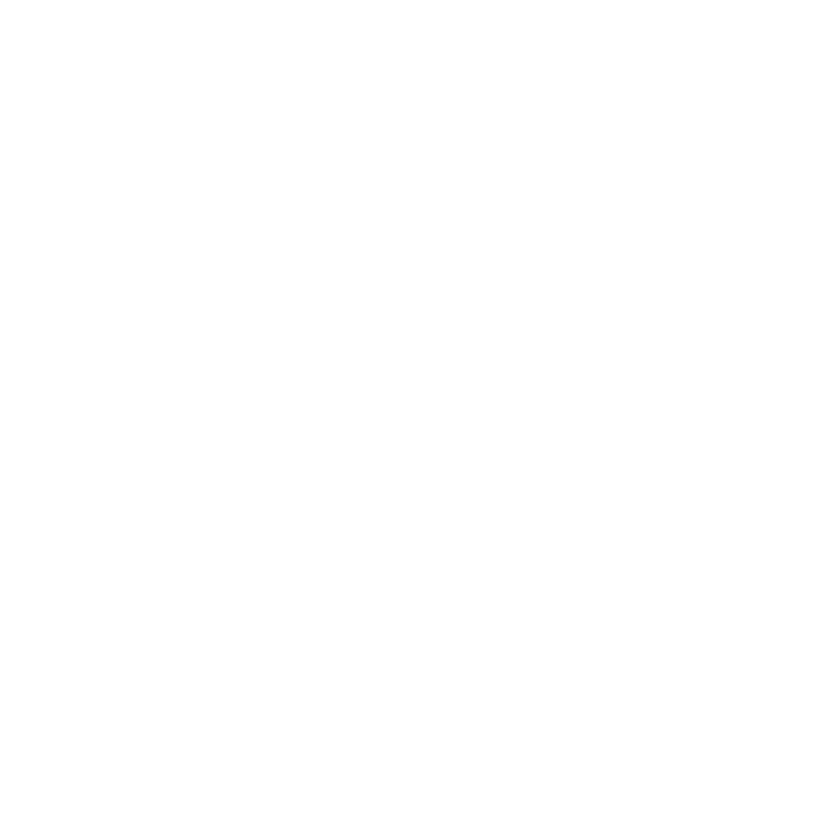

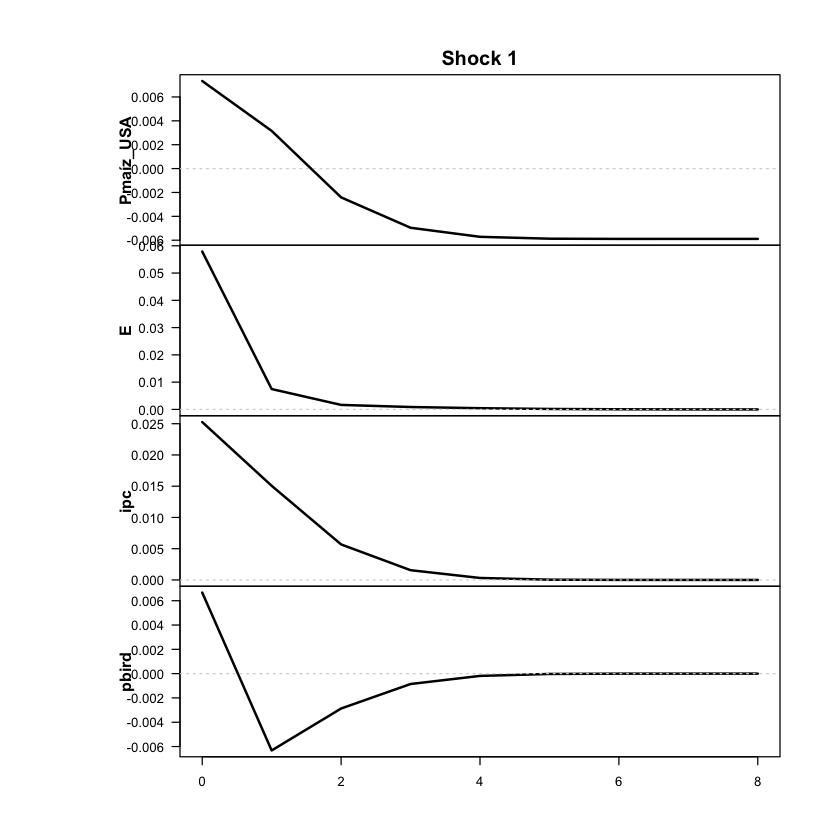

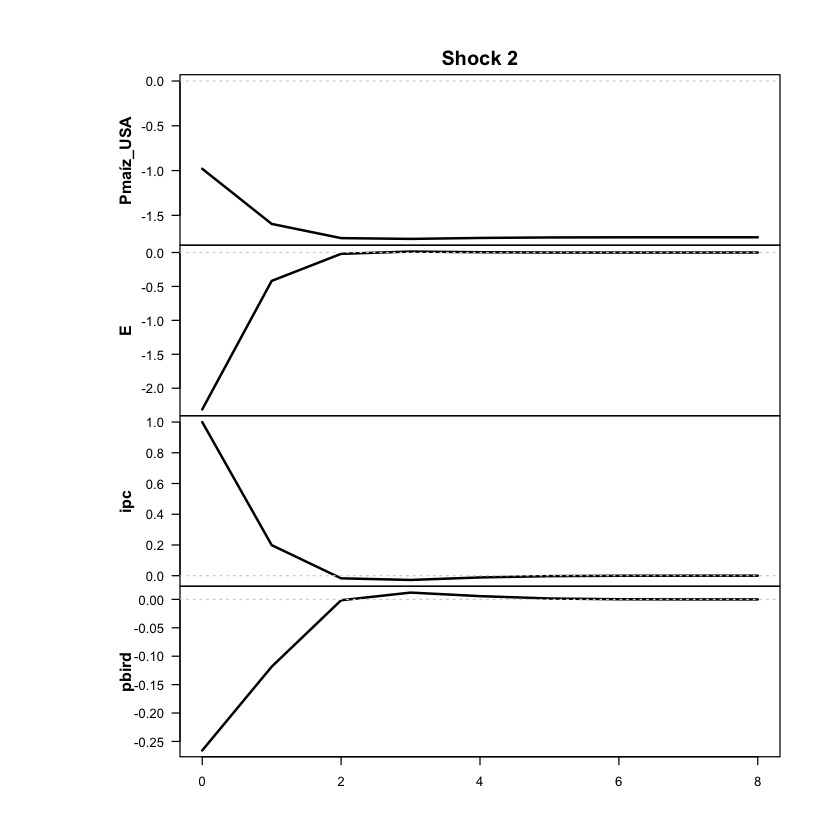

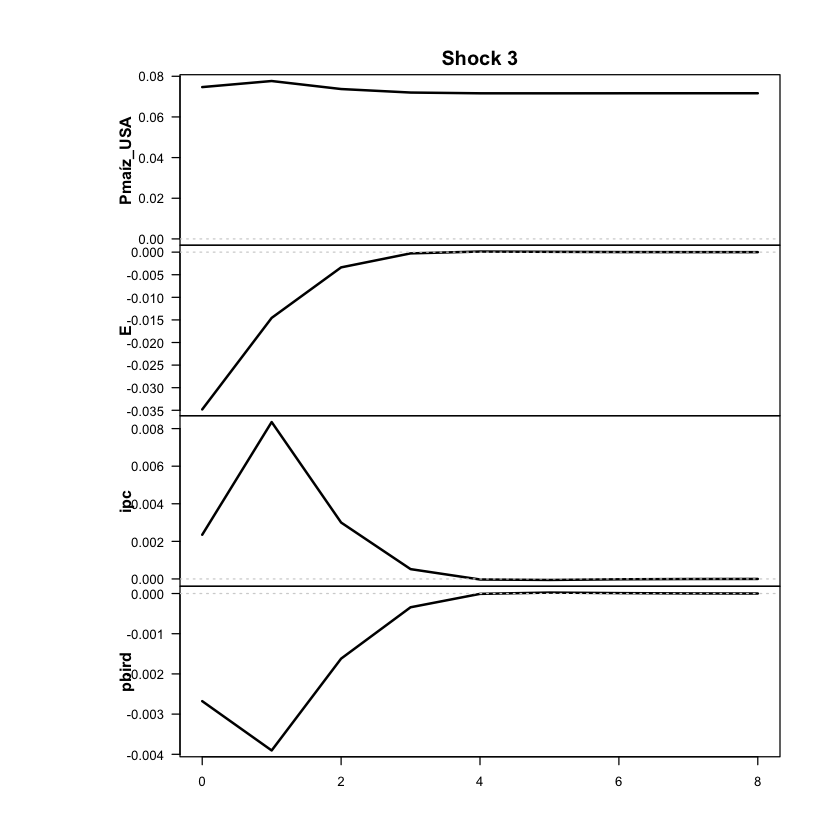

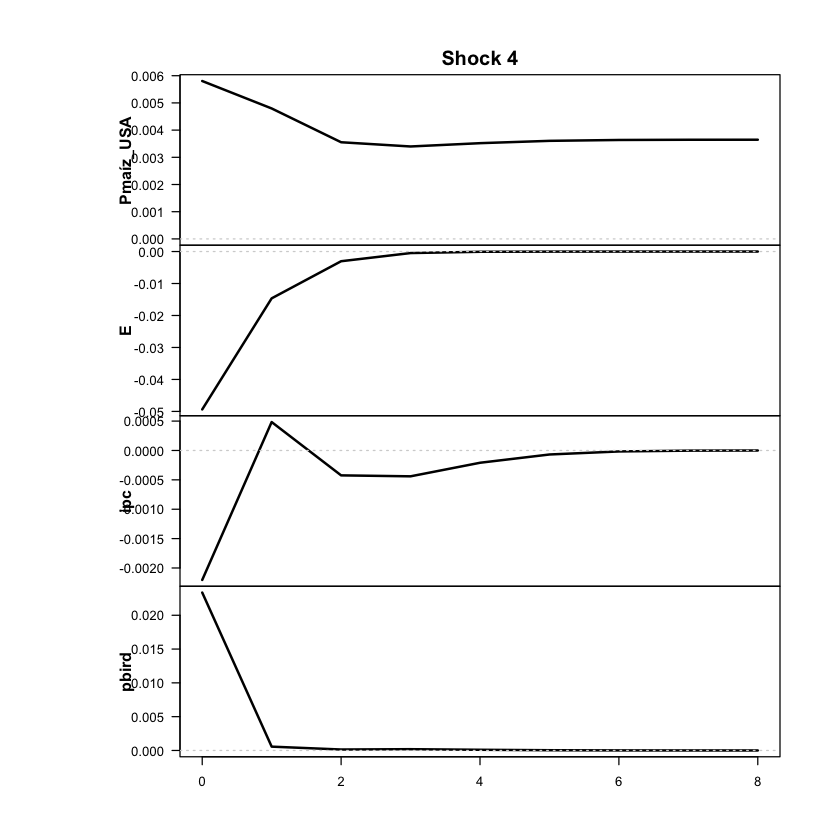

+++++++++ RÉGIMEN  2 +++++++++
 >>> GIRF ( 1  shock units)


Using 6 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



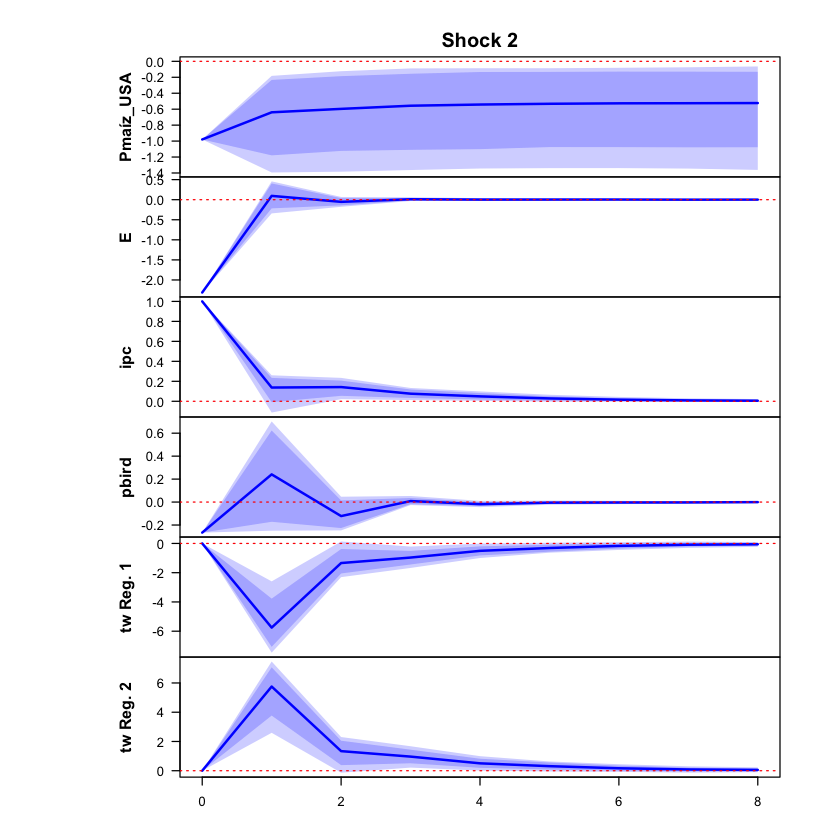

 >>> Linear IRF ( 1  shock units)


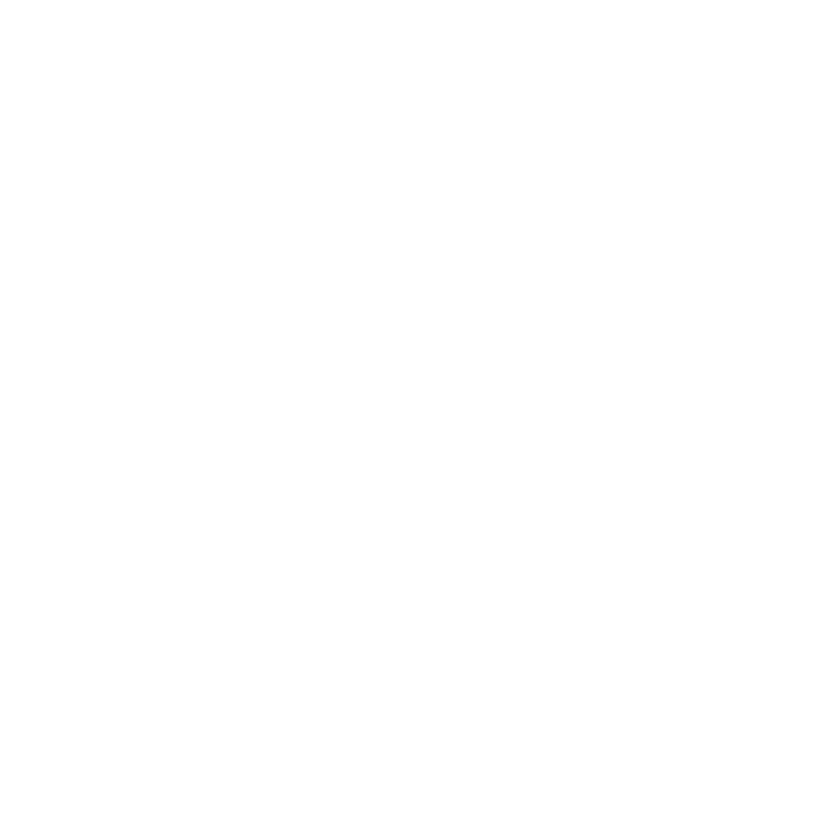

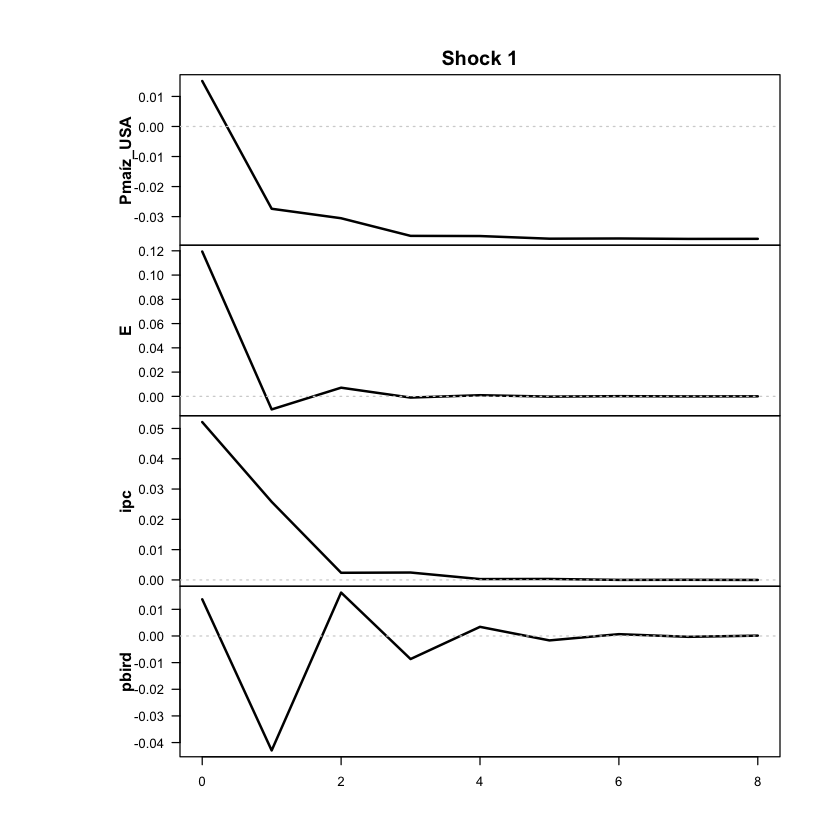

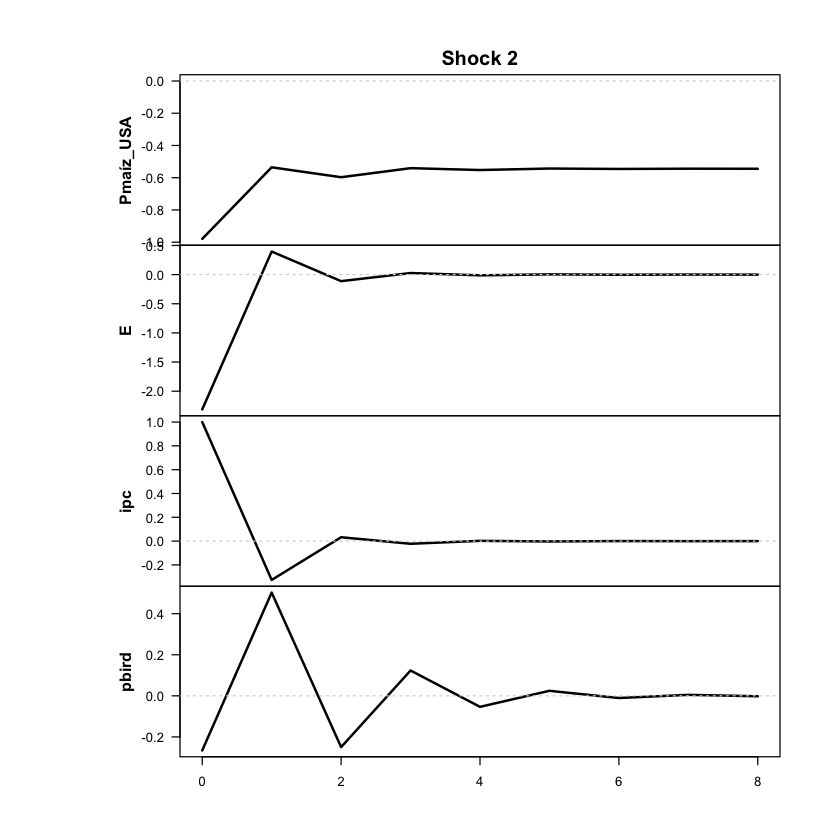

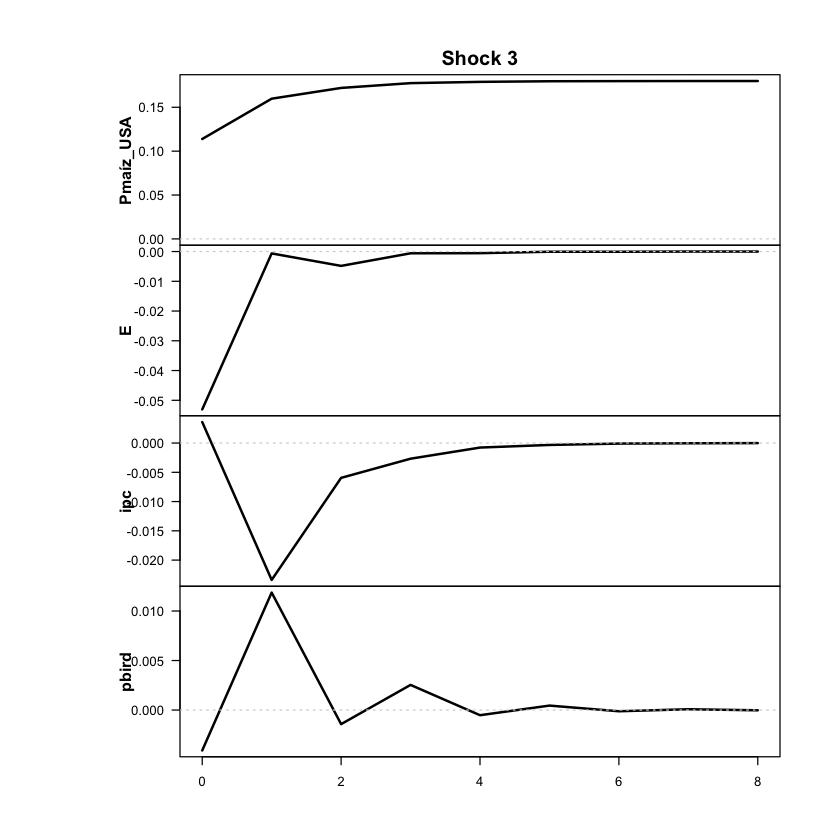

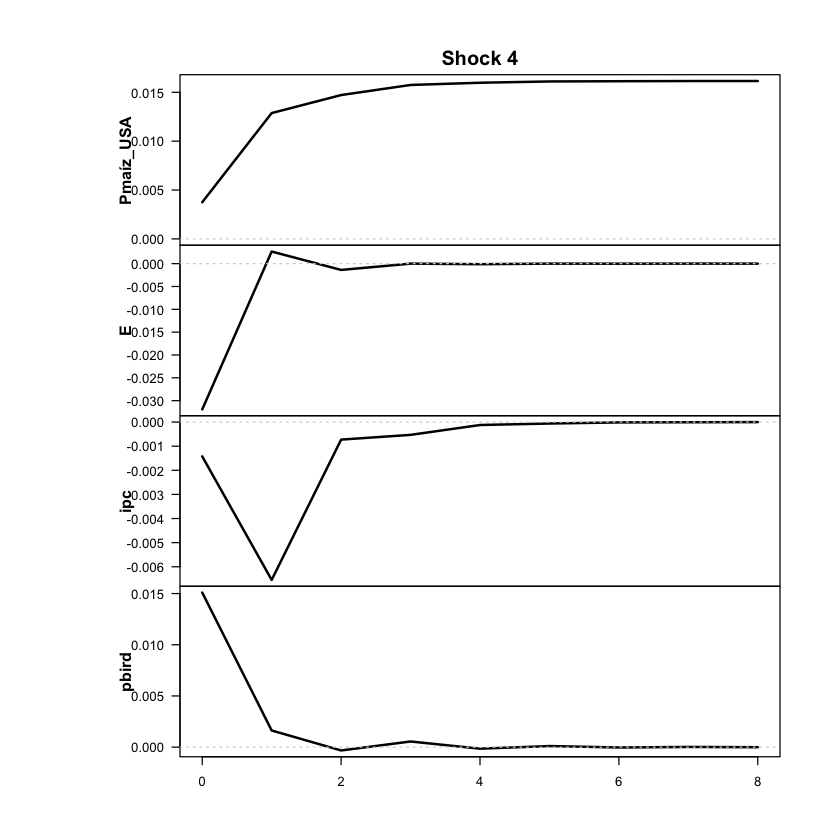

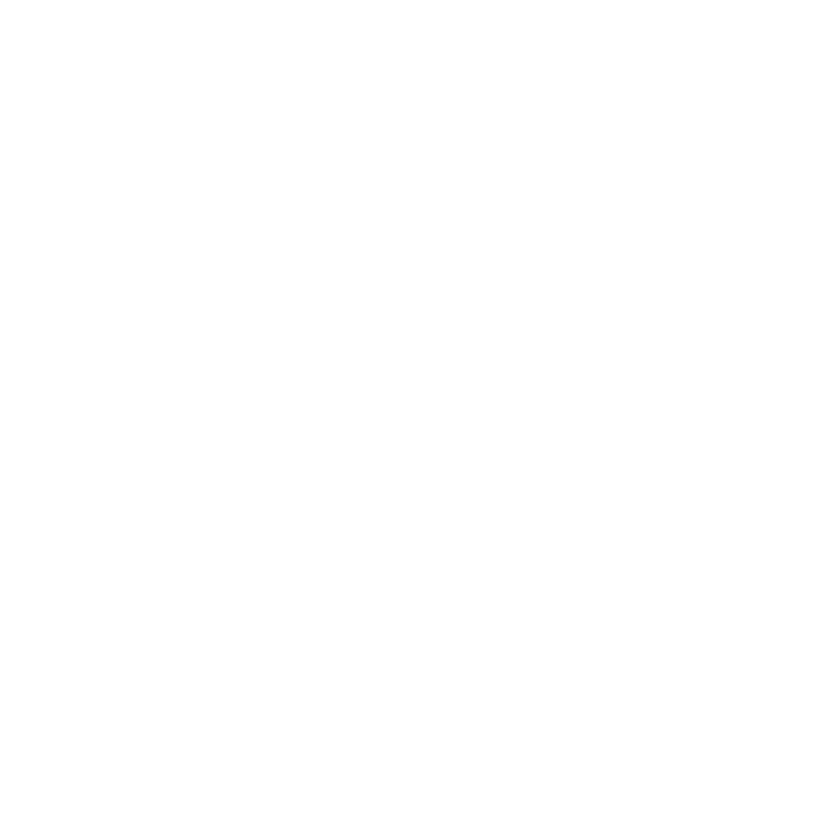

In [4]:
res <- run_threshold_tvar(
  data = df_ERPT_Arg_1950_74,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual' o mensual
  feature_lag = 1,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = TRUE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 500, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = FALSE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)

In [5]:
cat("RESULTADOS GIRF\n")
print_girf(res) #Si querés ver los resultados de GIRF, descomentame
cat("\nRESULTADOS IRF\n")
print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame

RESULTADOS GIRF
The responses of the variables Pmaíz_USA were cumulated. 

The GIRF of shock 2: 
The response of Pmaíz_USA: 
   2.5%   10%  mean   90% 97.5%
0 -0.98 -0.98 -0.98 -0.98 -0.98
1 -1.60 -1.58 -1.47 -1.30 -1.04
2 -1.74 -1.71 -1.55 -1.30 -1.03
3 -1.76 -1.72 -1.53 -1.26 -0.97
4 -1.76 -1.71 -1.52 -1.24 -0.95
5 -1.75 -1.71 -1.51 -1.23 -0.95
6 -1.76 -1.71 -1.51 -1.23 -0.93
7 -1.76 -1.71 -1.51 -1.23 -0.91
8 -1.76 -1.71 -1.51 -1.23 -0.90

The response of E: 
   2.5%   10%  mean   90% 97.5%
0 -2.31 -2.31 -2.31 -2.31 -2.31
1 -0.44 -0.43 -0.38 -0.30 -0.22
2 -0.06 -0.04  0.00  0.03  0.06
3 -0.02 -0.01  0.02  0.04  0.06
4 -0.03 -0.02  0.01  0.03  0.04
5 -0.03 -0.02  0.00  0.01  0.03
6 -0.02 -0.01  0.00  0.01  0.02
7 -0.02 -0.01  0.00  0.01  0.02
8 -0.01 -0.01  0.00  0.01  0.01

The response of ipc: 
   2.5%   10% mean  90% 97.5%
0  1.00  1.00 1.00 1.00  1.00
1  0.20  0.21 0.27 0.35  0.44
2 -0.01  0.00 0.06 0.14  0.22
3 -0.03 -0.01 0.03 0.08  0.13
4 -0.02 -0.01 0.02 0.05  0.09
5 -0.01  0.

In [6]:
res <- run_threshold_tvar(
  data = df_ERPT_Arg_1950_74,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual' o mensual
  feature_lag = 3,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = TRUE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 500, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = TRUE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)

Warning message in gzfile(file, "rb"):
“cannot open compressed file 'models/threshold_tvar_3_2_500_a43482305184f0d7f18c482d1b345880.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [ ]:
cat("RESULTADOS GIRF\n")
print_girf(res) #Si querés ver los resultados de GIRF, descomentame
cat("\nRESULTADOS IRF\n")
print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame

RESULTADOS GIRF
The responses of the variables Pmaíz_USA were cumulated. 

The GIRF of shock 2: 
The response of Pmaíz_USA: 
   2.5%   10%  mean   90% 97.5%
0 -0.24 -0.24 -0.24 -0.24 -0.24
1 -0.41 -0.40 -0.36 -0.30 -0.25
2 -0.23 -0.22 -0.19 -0.15 -0.09
3 -0.22 -0.19 -0.15 -0.11 -0.09
4 -0.25 -0.21 -0.16 -0.12 -0.10
5 -0.26 -0.22 -0.16 -0.12 -0.09
6 -0.28 -0.23 -0.17 -0.11 -0.09
7 -0.31 -0.25 -0.17 -0.11 -0.09
8 -0.34 -0.27 -0.17 -0.11 -0.09

The response of E: 
   2.5%   10%  mean   90% 97.5%
0 -3.29 -3.29 -3.29 -3.29 -3.29
1 -1.00 -0.94 -0.49  0.24  0.59
2 -0.06  0.03  0.28  0.67  0.95
3 -0.22 -0.10  0.14  0.42  0.69
4 -0.21 -0.14  0.07  0.33  0.54
5 -0.18 -0.10  0.08  0.32  0.50
6 -0.19 -0.11  0.06  0.25  0.41
7 -0.17 -0.10  0.06  0.23  0.42
8 -0.17 -0.09  0.04  0.19  0.32

The response of ipc: 
   2.5%   10% mean  90% 97.5%
0  1.00  1.00 1.00 1.00  1.00
1 -0.20 -0.18 0.07 0.42  0.63
2 -0.16 -0.12 0.13 0.51  0.76
3 -0.16 -0.08 0.13 0.42  0.72
4 -0.17 -0.10 0.09 0.37  0.55
5 -0.16 -0.

## Ejemplo VLSTAR (logistic)

Using 2 cores for 500 estimations rounds...

PHASE 1: Estimating all the parameters with a genetic algorithm...

Results from the genetic algorithm:

The lowest loglik:  1237.027

The largest loglik: 1491.62

PHASE 2: Estimating all the parameters with a variable metric algorithm...

Results from the variable metric algorithm:

The lowest loglik:  1237.027

The largest loglik: 1491.62

Filtering inappropriate estimates...

No 'appropriate'estimates found! Check that all the variables are scaled to vary in similar magninutes, also not very small or large magnitudes.

Consider running more estimation rounds or study the obtained estimates one-by-one with the function alt_stvar.

Calculating approximate standard errors...

Warning message in warn_eigens(ret, allow_unstab = allow_unstab):
“Regimes 1 and 2 have near-singular error term covariance matrices! Consider building a model from the next-largest local maximum with the function 'alt_stvar' by adjusting its argument 'which_largest' (o

========= Unstructured fitted model ==========


Calculating approximate standard errors...



========= Structured fitted model (heteroskedasticity) ==========
Saving trained models to models/ folder

 >>> DIAGNOSTIC PLOTS


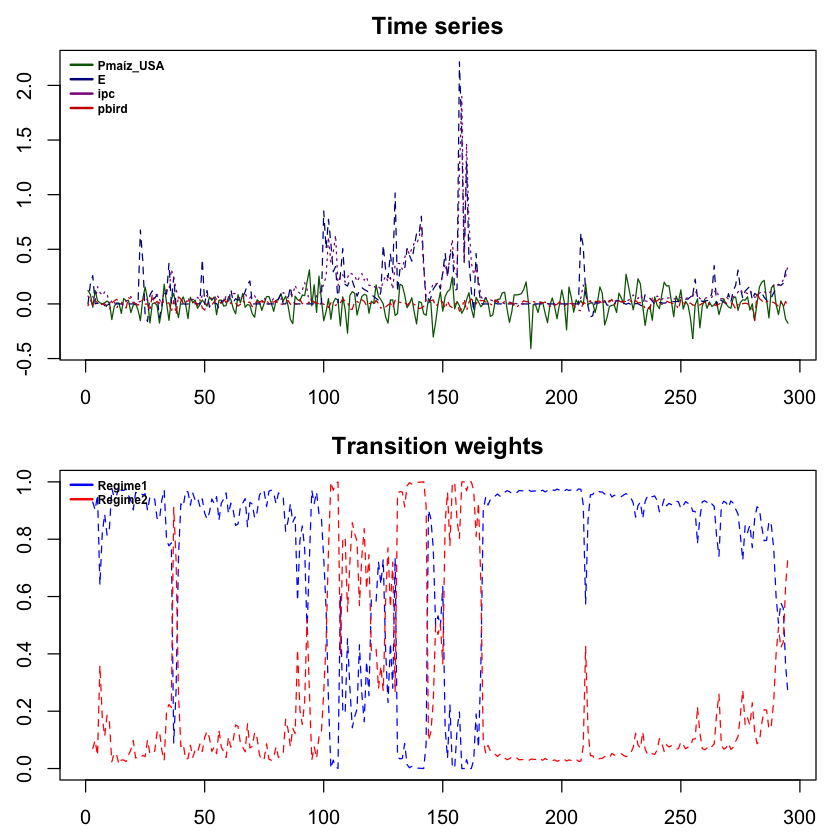

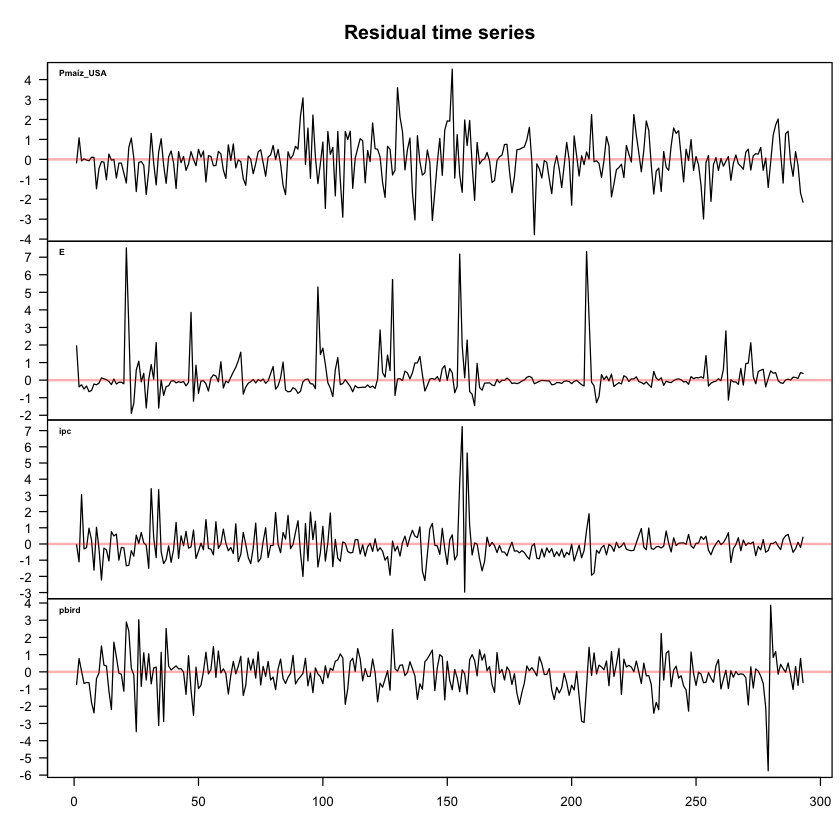

+++++++++ RÉGIMEN  1 +++++++++
 >>> GIRF


Using 2 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



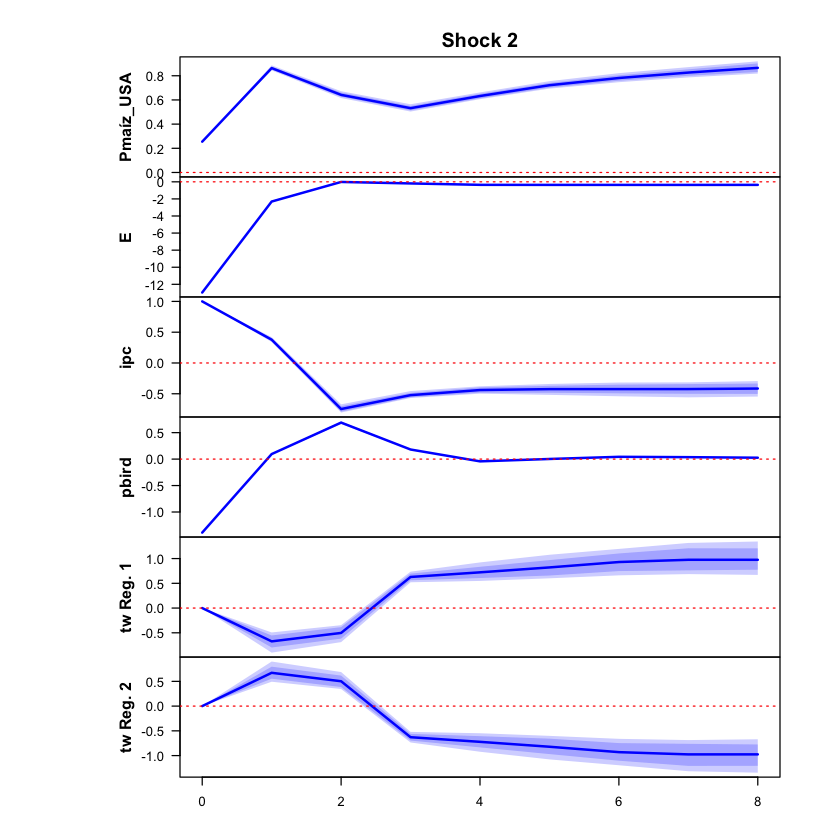

 >>> Linear IRF (1 shock)

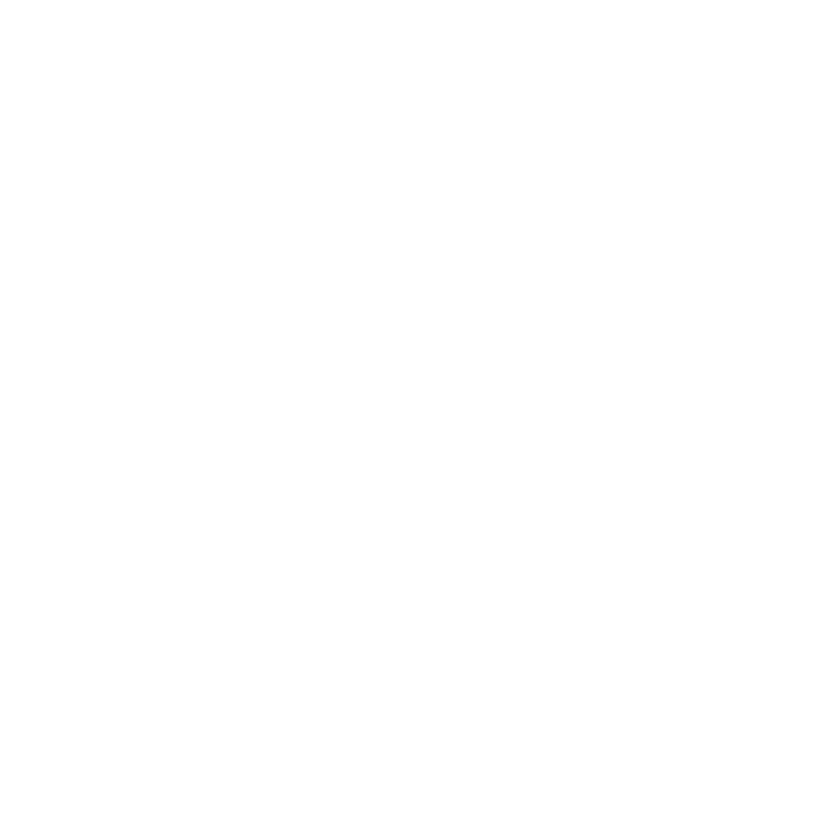

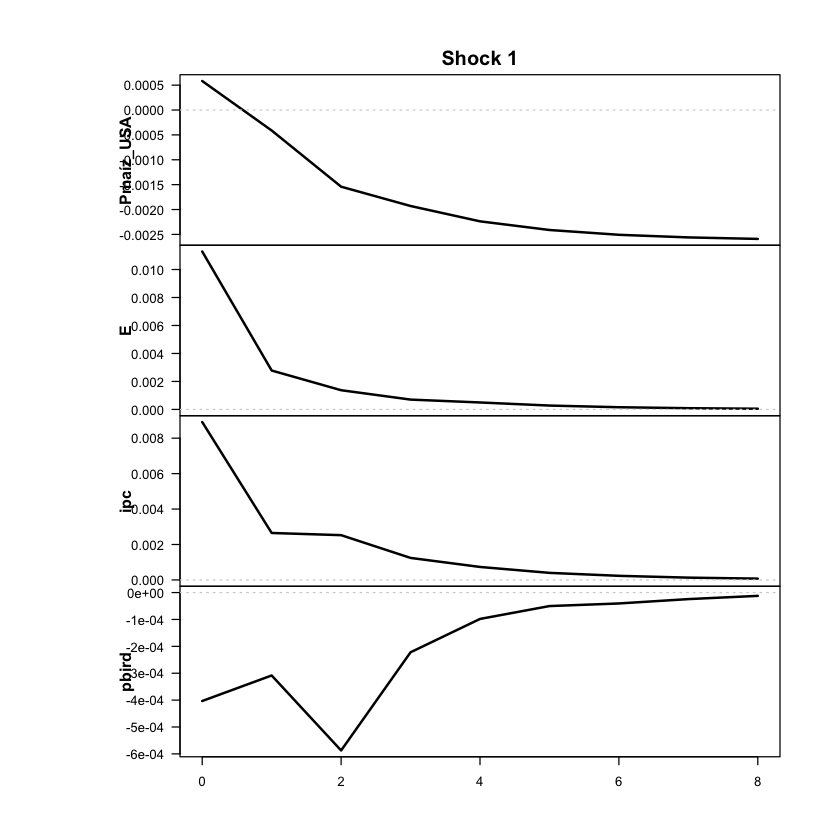

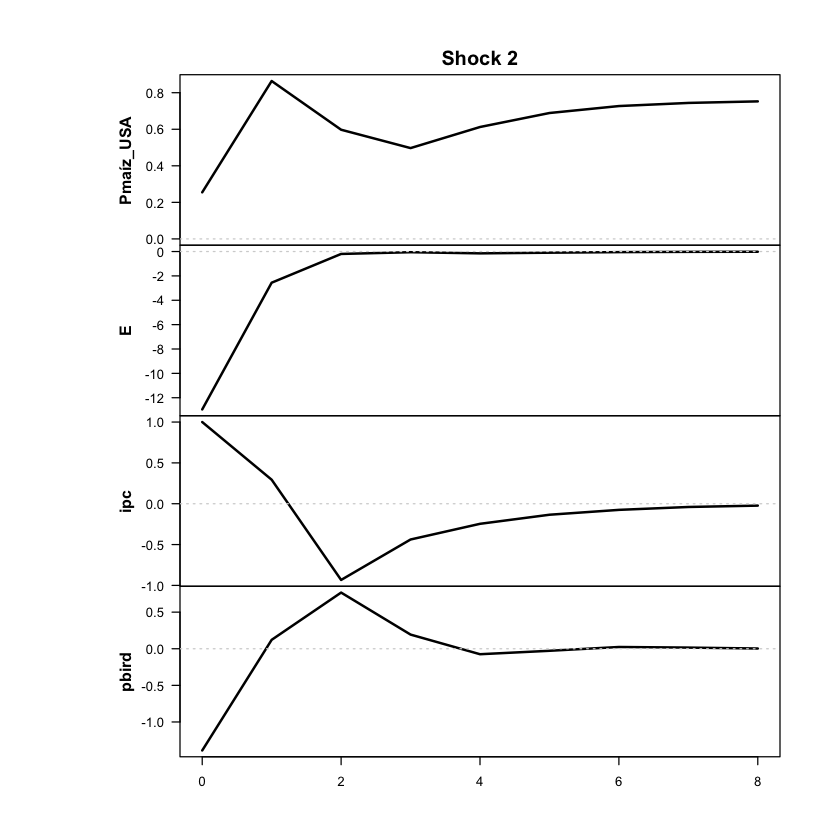

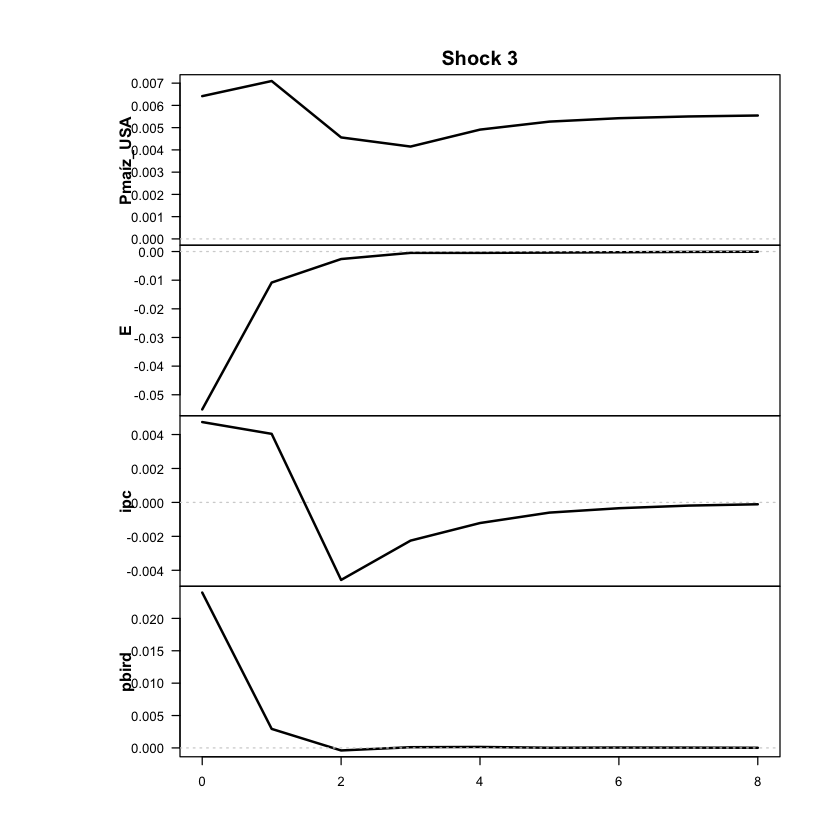

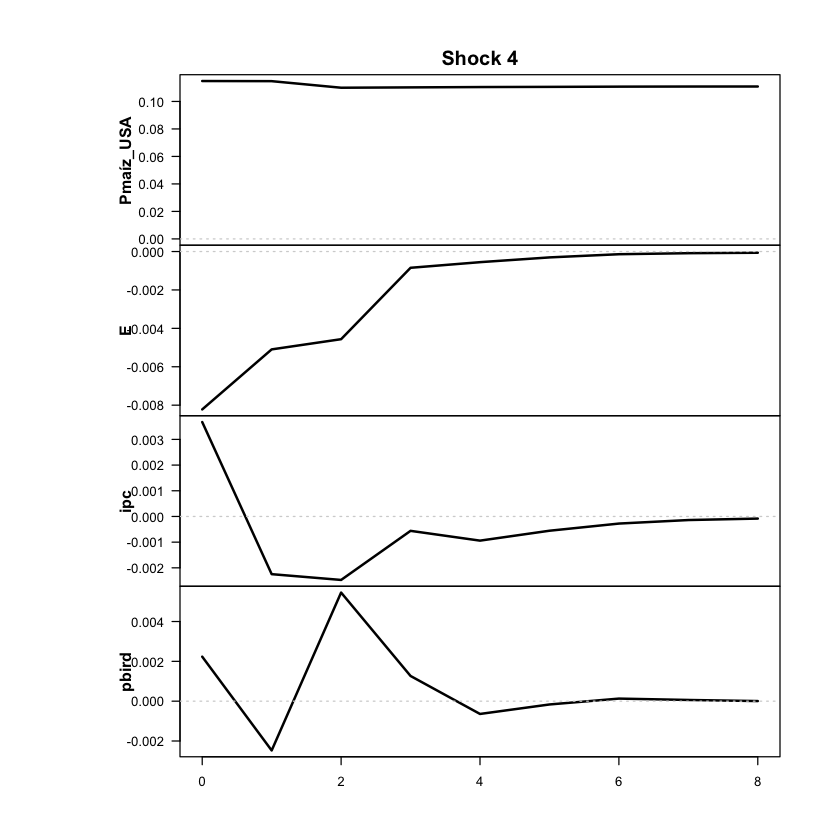

+++++++++ RÉGIMEN  2 +++++++++
 >>> GIRF


Using 2 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



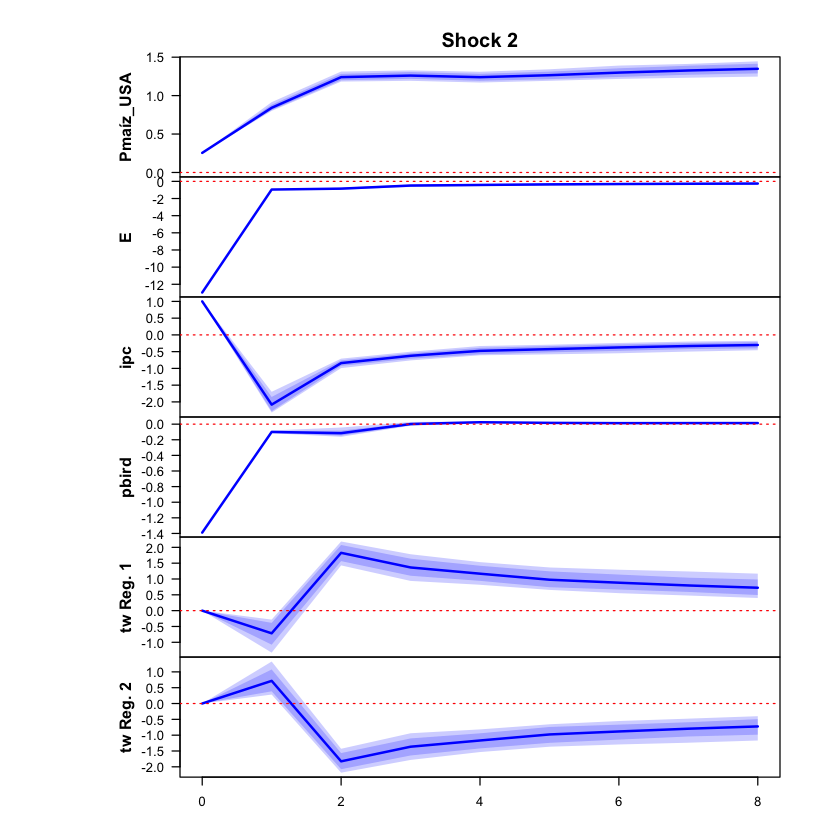

 >>> Linear IRF (1 shock)

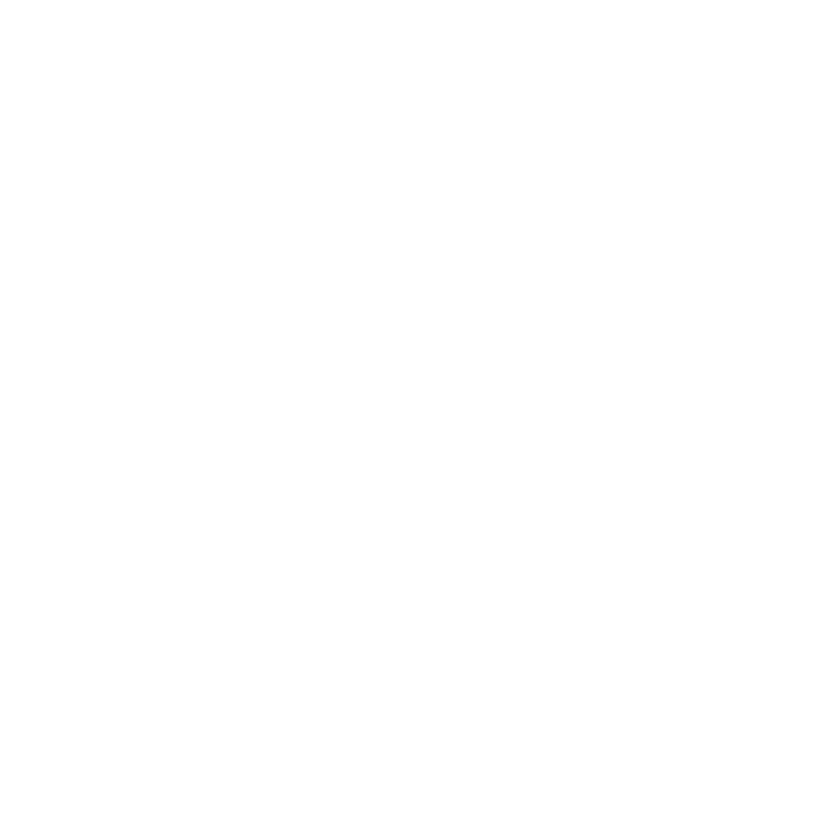

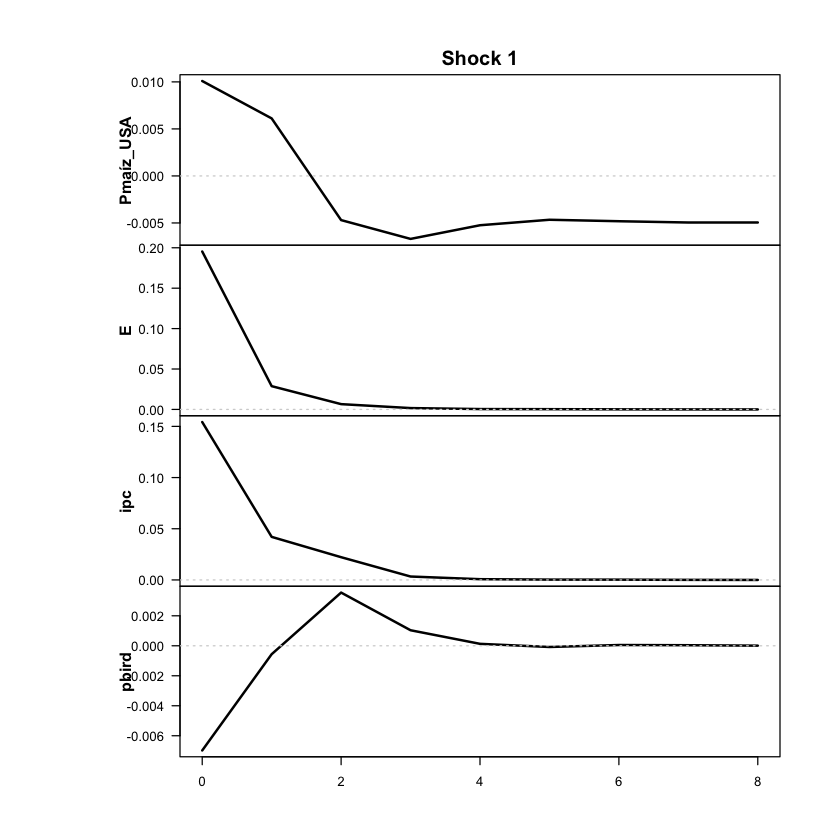

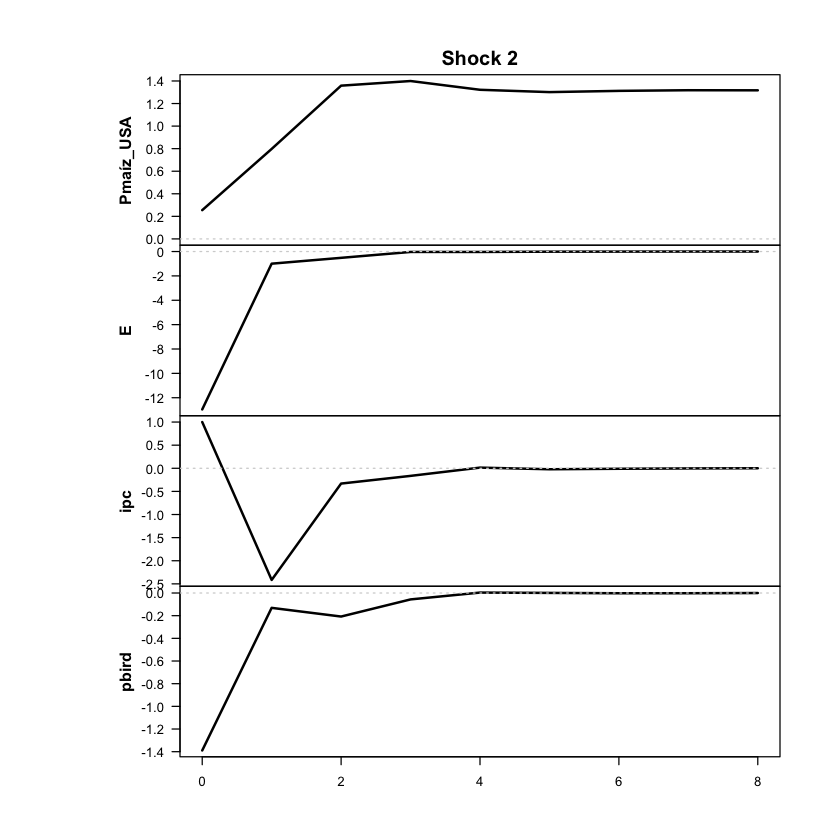

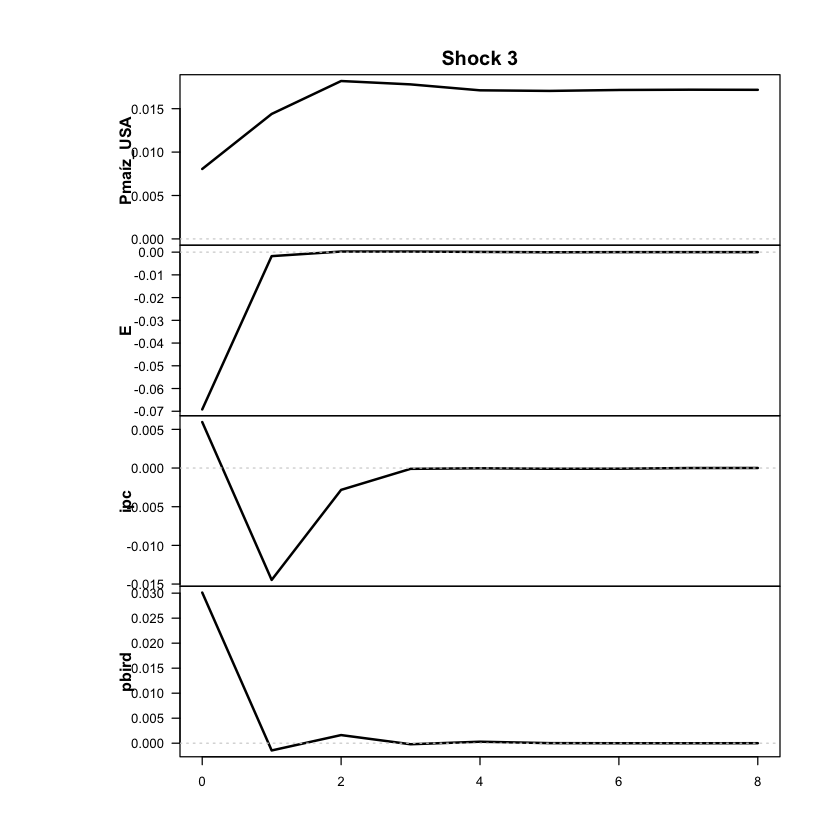

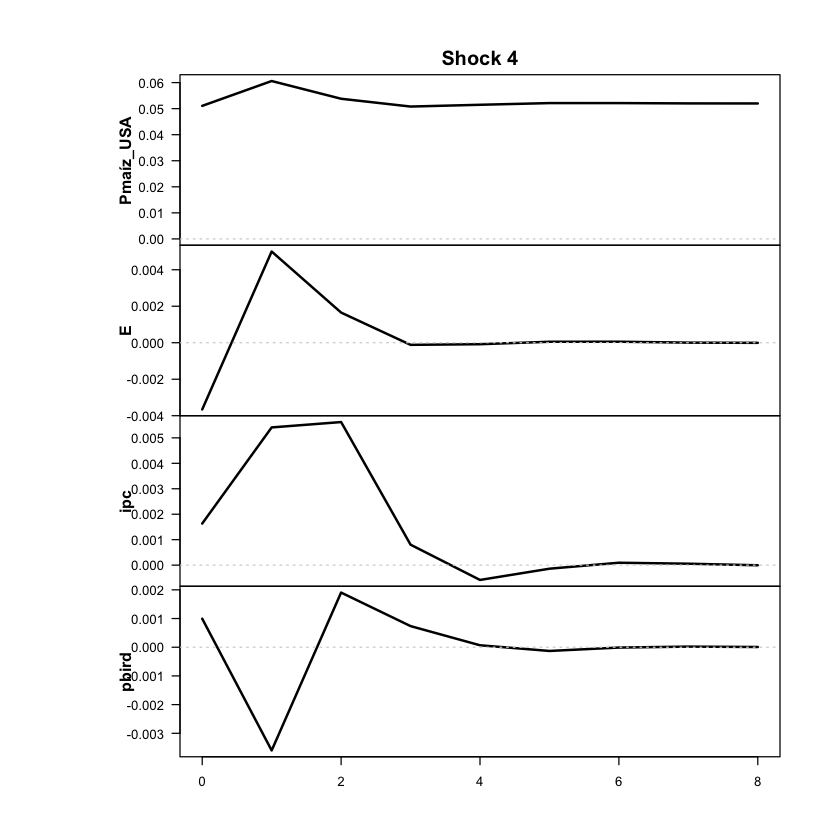

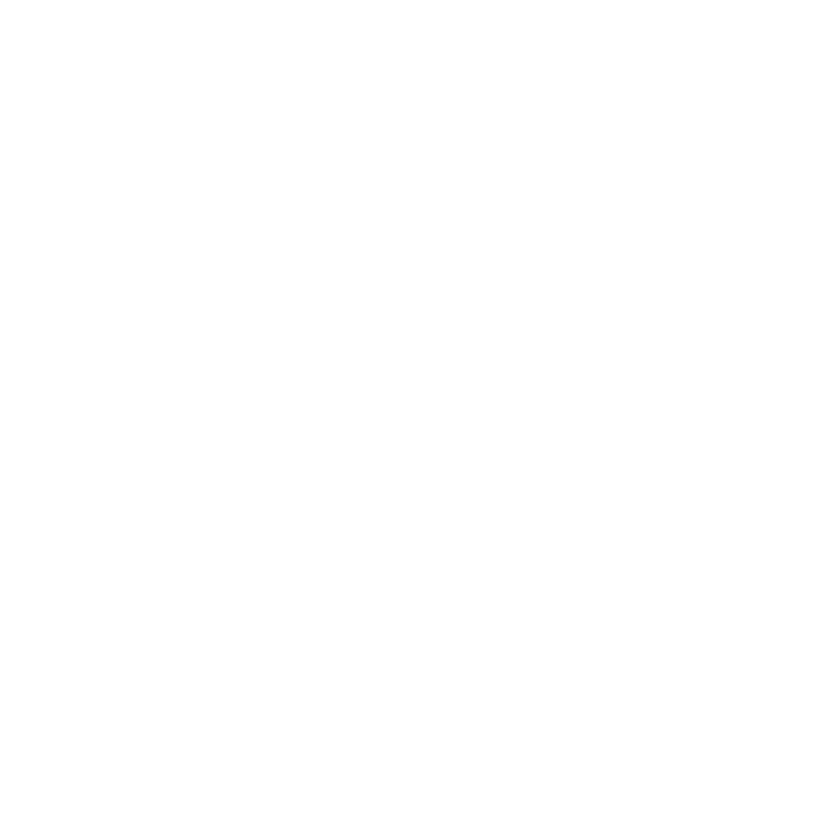

In [ ]:
res <- run_vlstar (
  data = df_ERPT_Arg_1950_74,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual'
  feature_lag = 1,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = FALSE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 500, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = FALSE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)

In [ ]:
cat("RESULTADOS GIRF\n")
print_girf(res) #Si querés ver los resultados de GIRF, descomentame
cat("\nRESULTADOS IRF\n")
print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame

Se cargó exitosamente modelos preguardados  vlstar_3_2_500_e011b7320c6008a5e64356020b5b9d43.rds  de la carpeta models

 >>> DIAGNOSTIC PLOTS


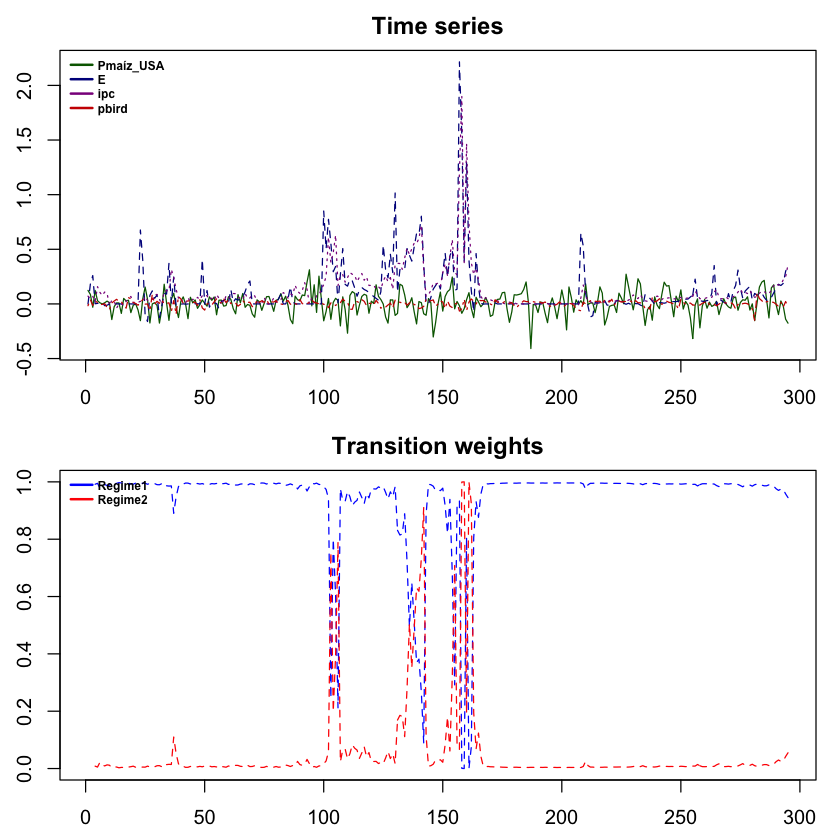

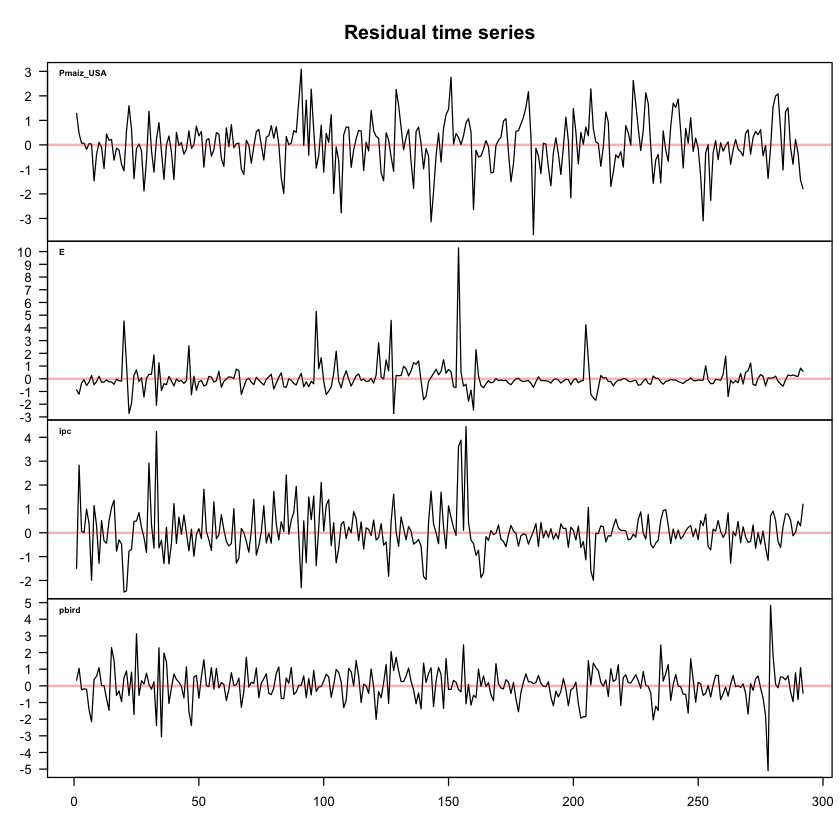

+++++++++ RÉGIMEN  1 +++++++++
 >>> GIRF ( 1  shock units)


Using 6 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



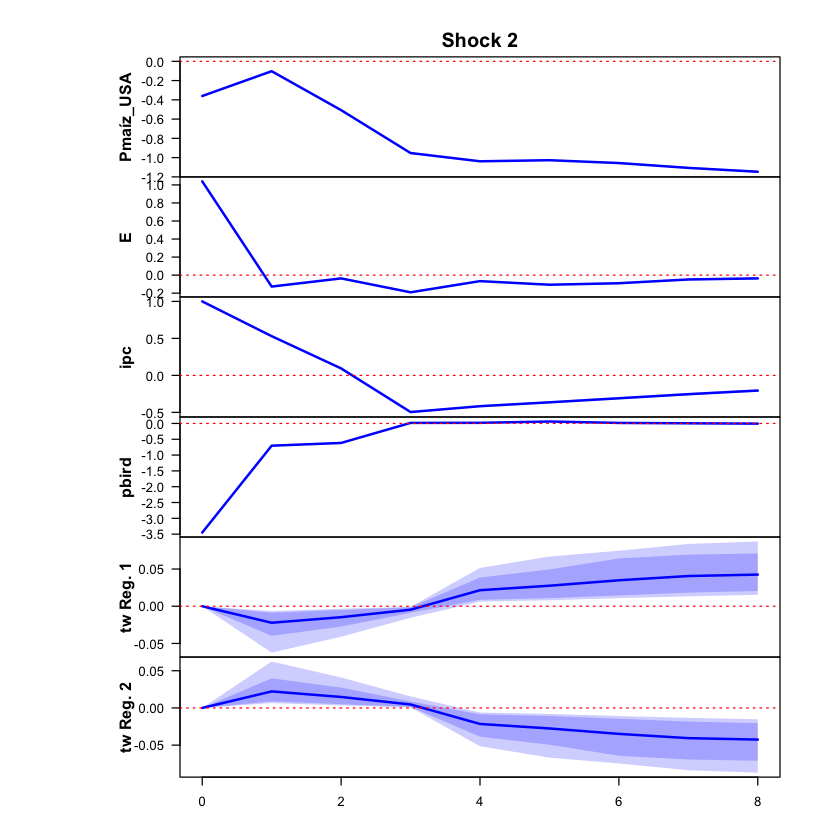

 >>> Linear IRF ( 1  shock units)


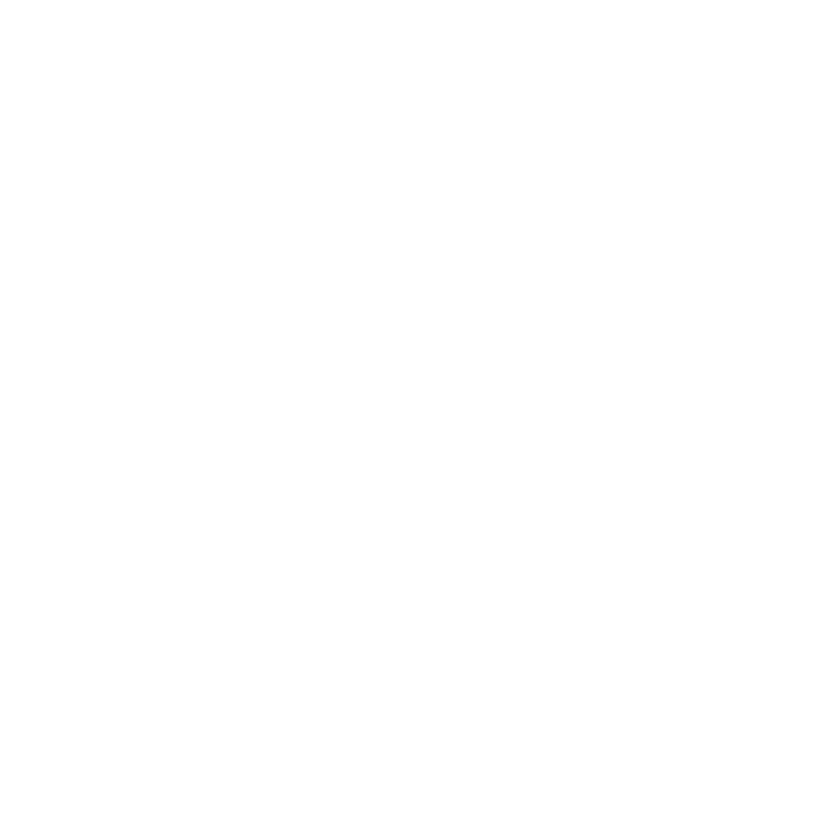

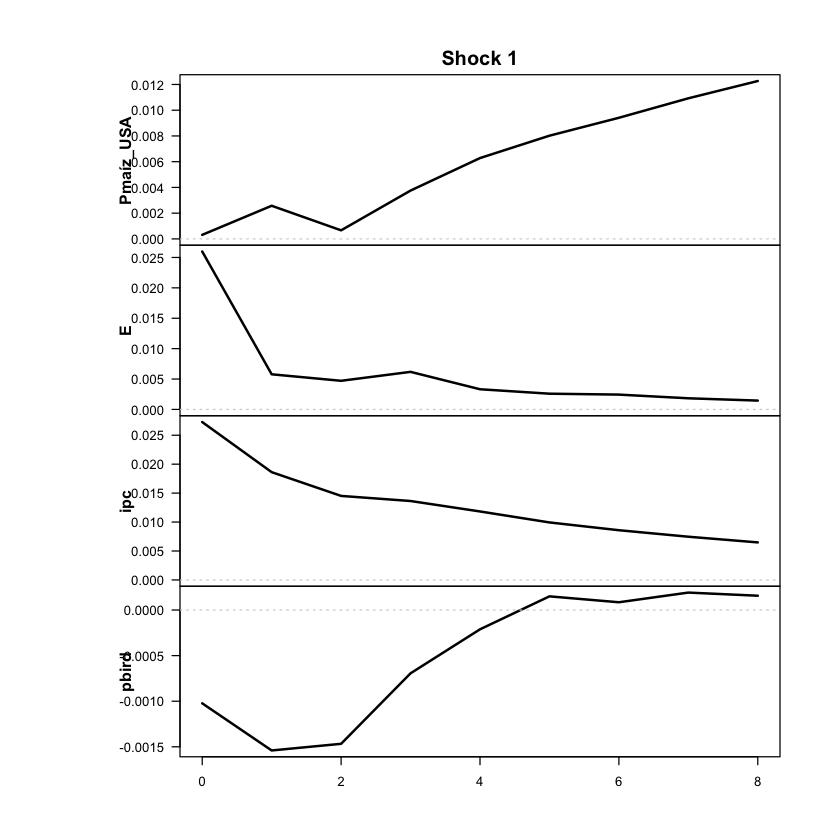

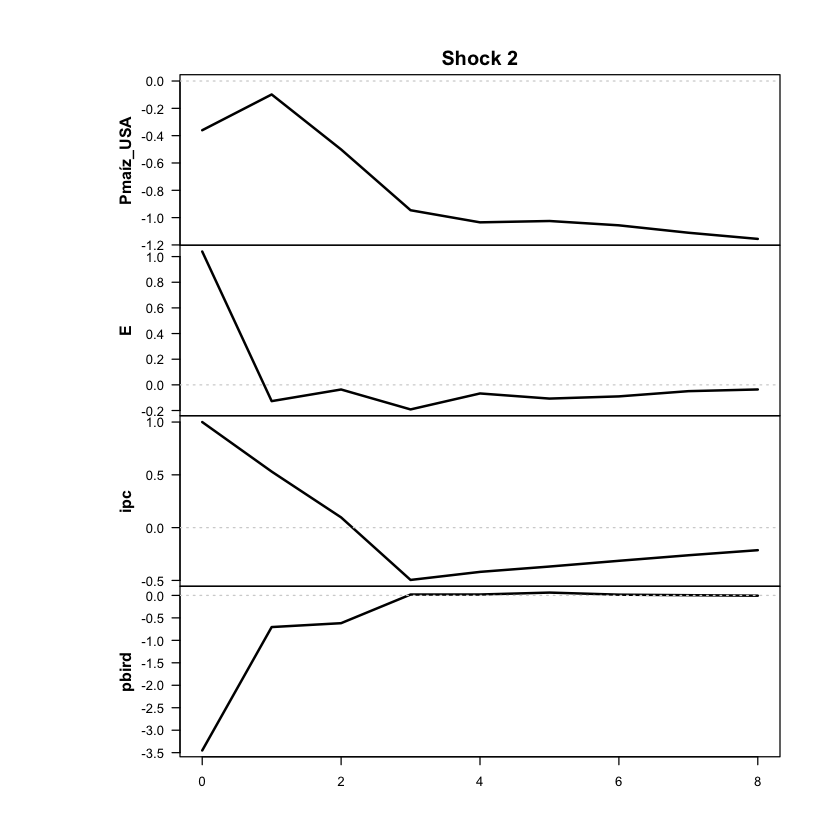

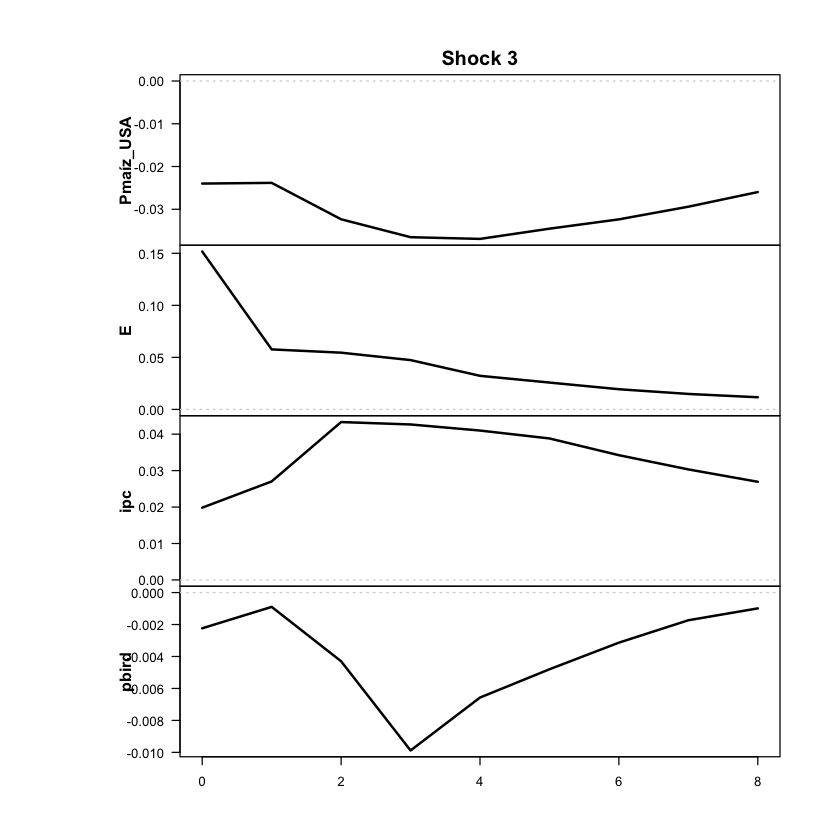

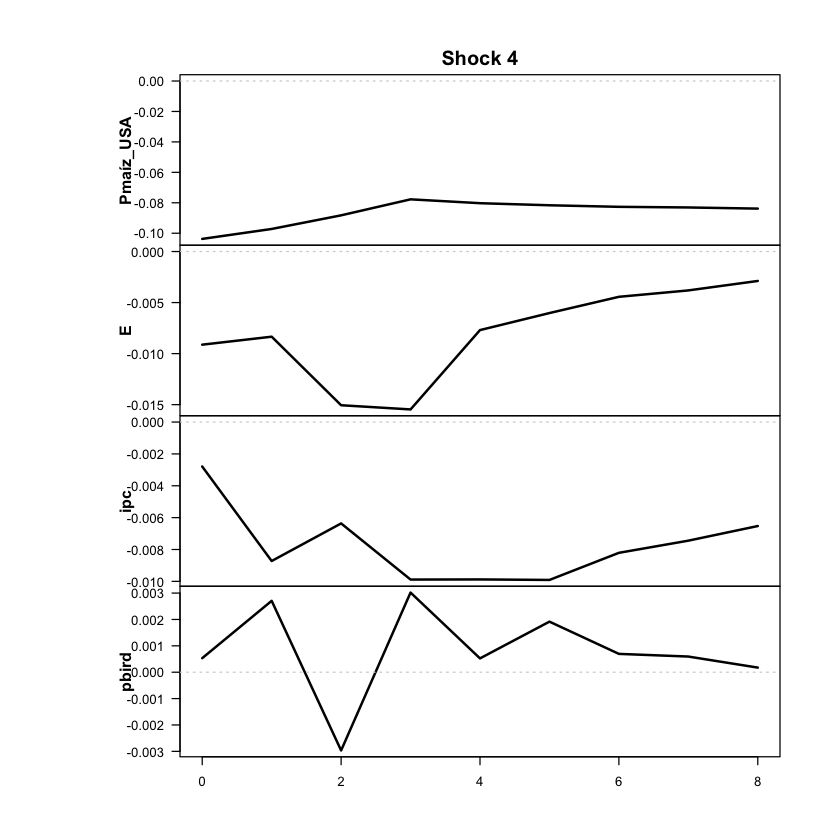

+++++++++ RÉGIMEN  2 +++++++++
 >>> GIRF ( 1  shock units)


Using 6 cores to estimate 250 GIRFs for 1 structural shocks, each based on 500 Monte Carlo repetitions.

Estimating GIRFs for structural shock 2...

Finished!



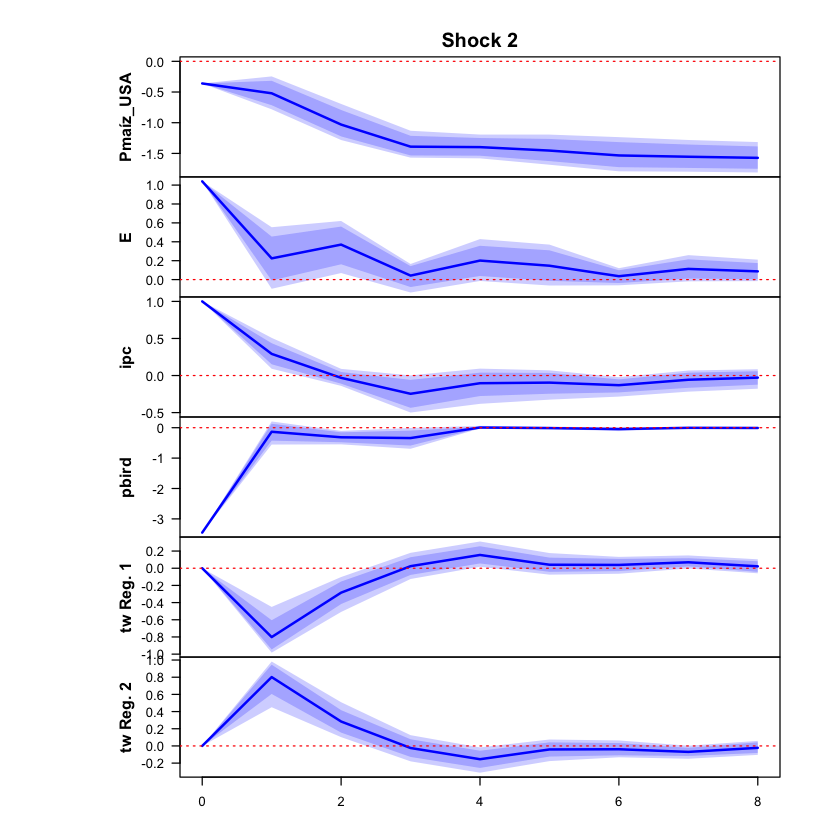

 >>> Linear IRF ( 1  shock units)


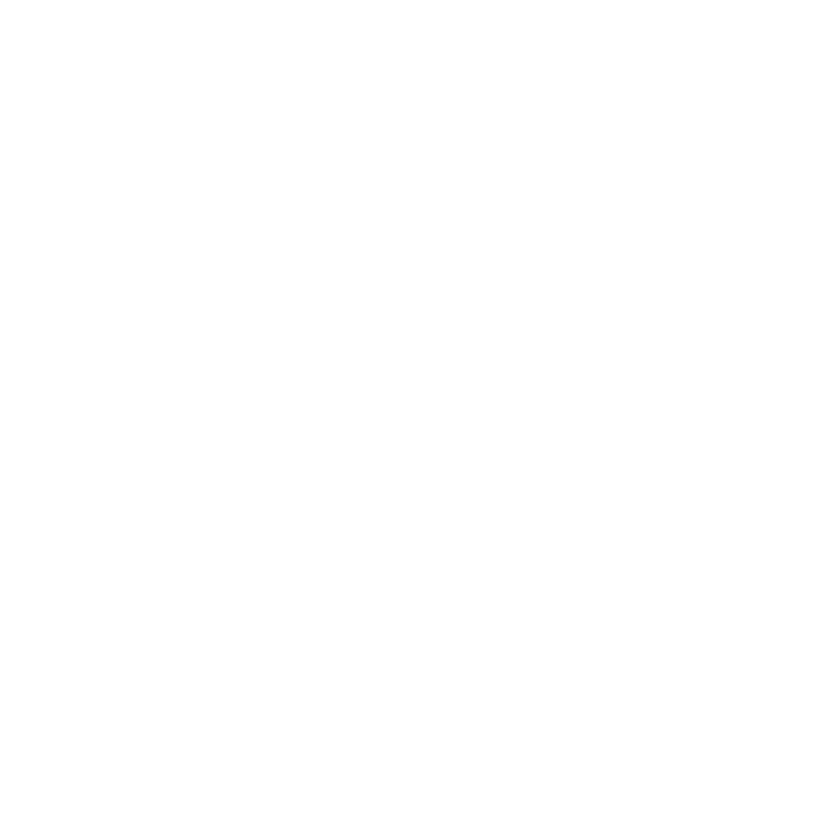

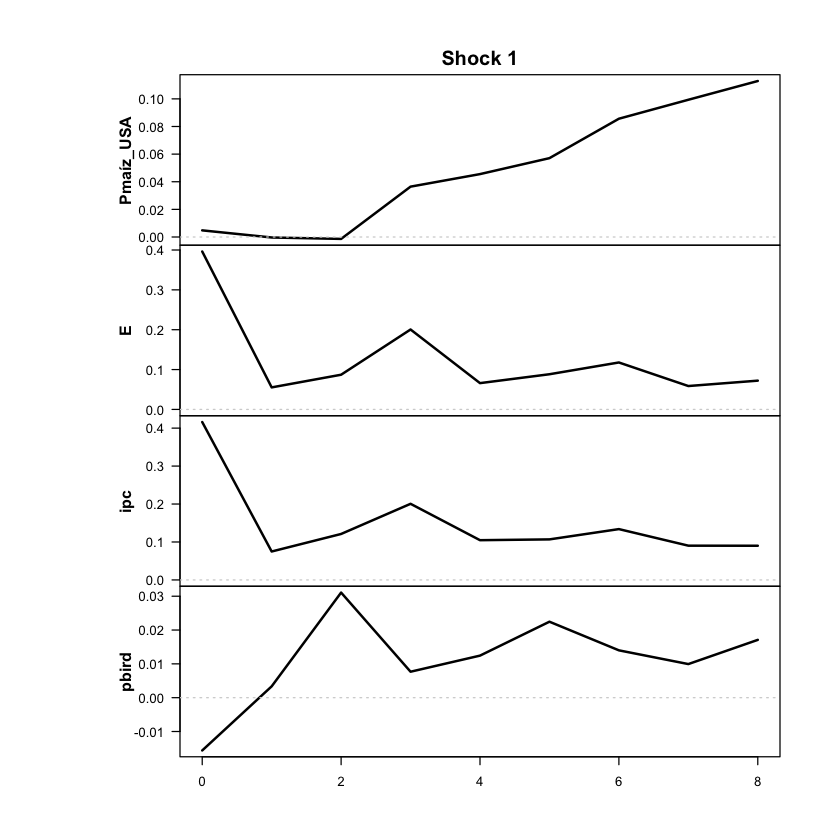

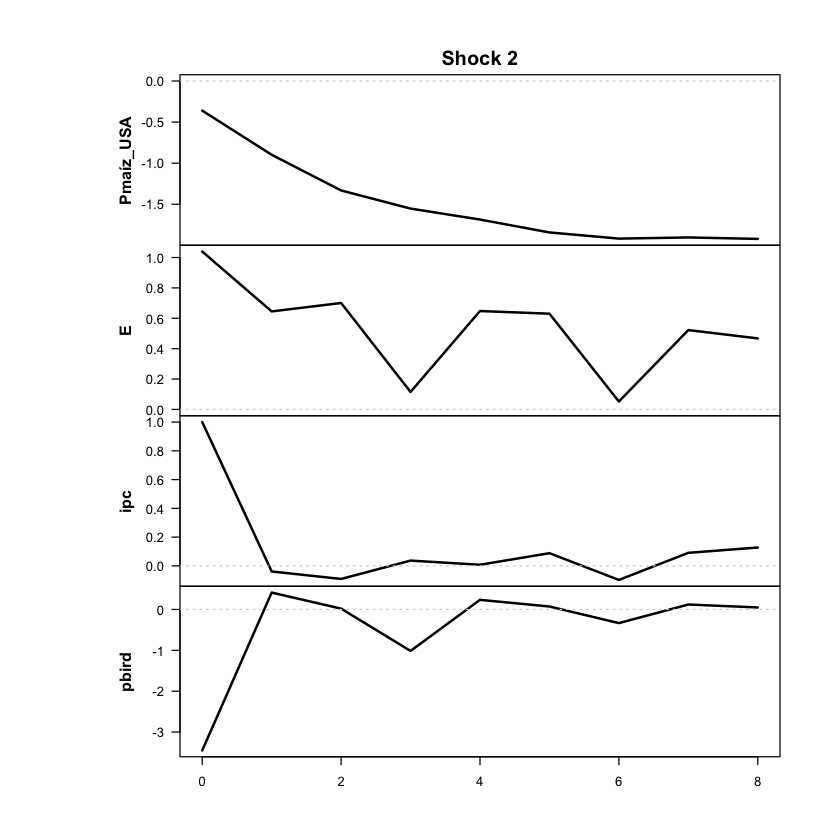

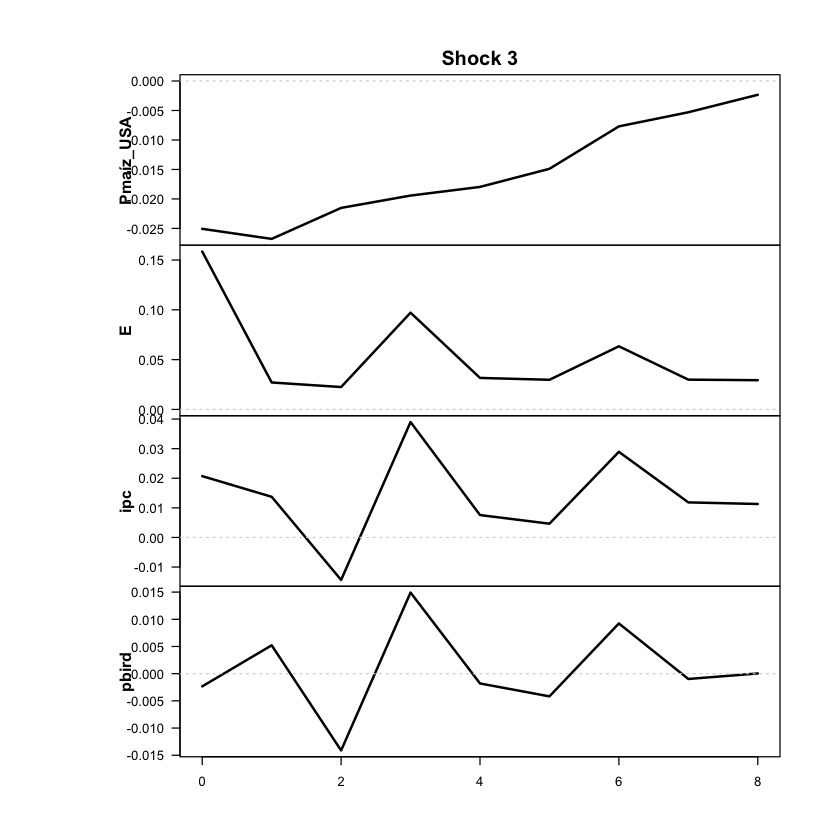

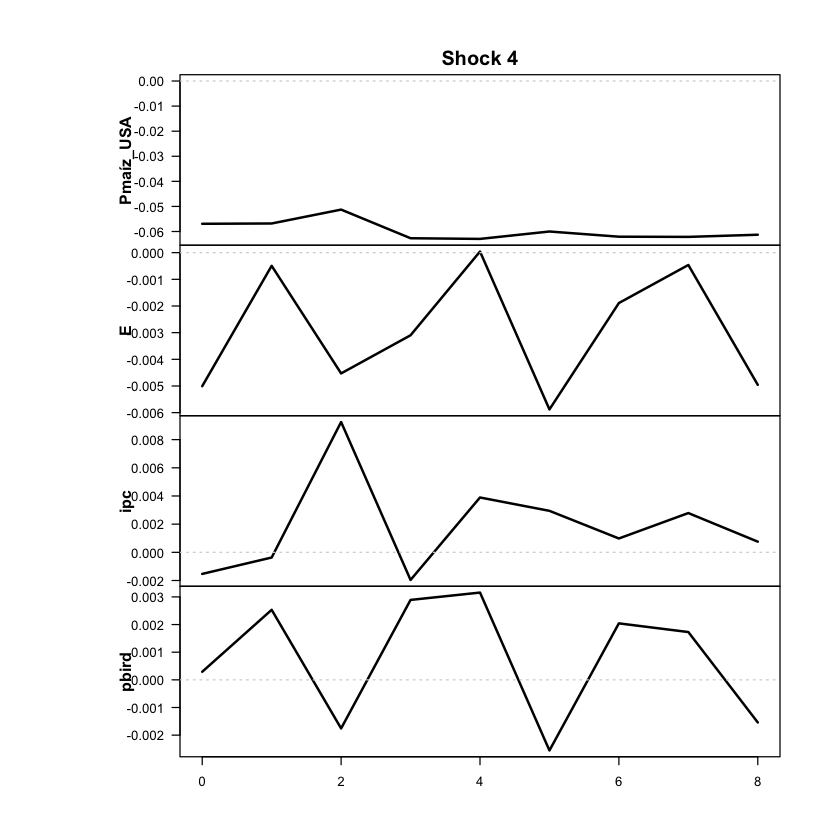

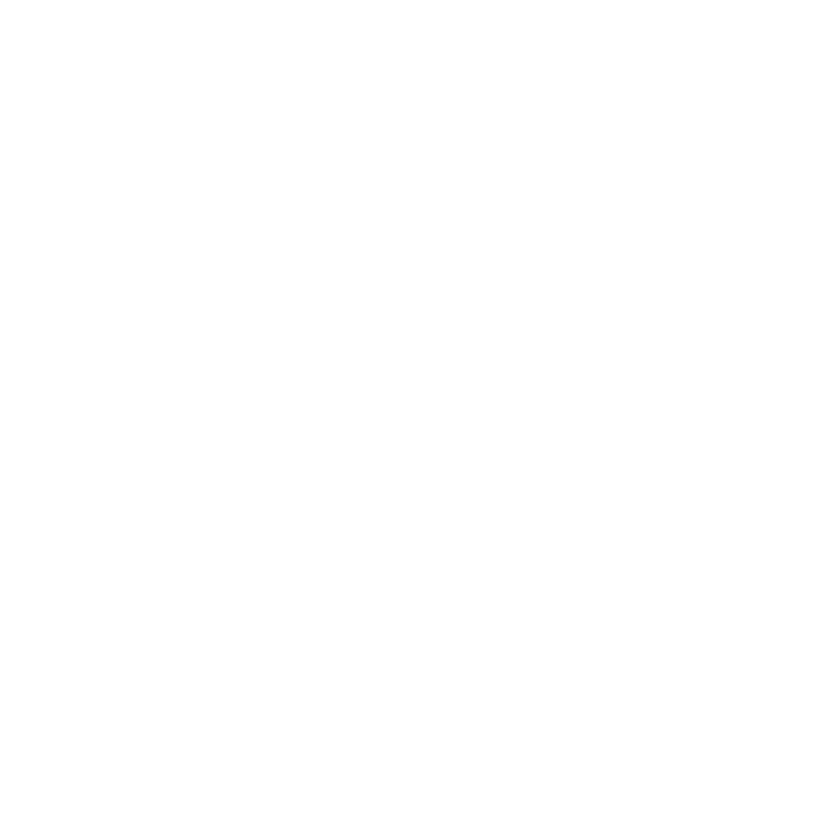

In [ ]:
res <- run_vlstar (
  data = df_ERPT_Arg_1950_74,
  endog = c("Pmaíz_USA","E","ipc","pbird"),
  periodicity = 'trimestral', # 'trimestral' o 'anual'
  feature_lag = 3,
  n_regimes = 2,
  cumulative = TRUE,
  thr_var = 'ipc', # 'ipc'
  thr_lag = 1,
  shock_var = 'E', # 'E'
  response_vars = c('ipc'), # c("Pmaíz_USA","ipc","pbird")
  run_tests = FALSE, # ejecuta e imprime tests: portmonteau, descomposición histórica y GEFVD
  irf_horizons = NULL, # Max períodos hacia los que mirar adelante en IRF (NULL = 2 años, default = 2 años)
  irf_shocks = 1, # Shocks unitarios irf (default 1)
  diagnostic_plots = TRUE, # Imprimir plots de diagnostico? TRUE o FALSE (default FALSE)
  nrounds = 500, # Cantidad de iteraciones - para ver resultados poco confiables rápido poner bajito, si no dejar en 500 o incluso 1000 (default 500)
  load_presaved = TRUE
)
#Correr los siguientes en celdas aparte
#print_girf(res) #Si querés ver los resultados de GIRF, descomentame
#print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame
# OJO: A ESTA HAY QUE PASARLE LOS MISMOS PARÁMETROS QUE A RUN_VLSTAR!!
#run_tests_sstvar(res, response_vars = c('ipc'), cumulative = TRUE, irf_horizons = NULL, irf_shocks = 1, nrounds = 1)

In [ ]:
cat("RESULTADOS GIRF\n")
print_girf(res) #Si querés ver los resultados de GIRF, descomentame
cat("\nRESULTADOS IRF\n")
print_irf(res) #Si querés ver los resultados de IRF lineal, descomentame

RESULTADOS GIRF
The responses of the variables Pmaíz_USA were cumulated. 

The GIRF of shock 2: 
The response of Pmaíz_USA: 
   2.5%   10%  mean   90% 97.5%
0 -0.36 -0.36 -0.36 -0.36 -0.36
1 -0.11 -0.11 -0.10 -0.10 -0.10
2 -0.52 -0.51 -0.51 -0.50 -0.50
3 -0.96 -0.96 -0.95 -0.95 -0.95
4 -1.05 -1.04 -1.04 -1.04 -1.04
5 -1.03 -1.03 -1.03 -1.02 -1.02
6 -1.06 -1.06 -1.06 -1.05 -1.05
7 -1.11 -1.11 -1.11 -1.10 -1.10
8 -1.15 -1.15 -1.15 -1.14 -1.13

The response of E: 
   2.5%   10%  mean   90% 97.5%
0  1.04  1.04  1.04  1.04  1.04
1 -0.14 -0.13 -0.13 -0.12 -0.12
2 -0.04 -0.04 -0.04 -0.03 -0.03
3 -0.19 -0.19 -0.19 -0.19 -0.19
4 -0.07 -0.07 -0.07 -0.06 -0.06
5 -0.12 -0.11 -0.11 -0.10 -0.10
6 -0.10 -0.10 -0.09 -0.08 -0.08
7 -0.06 -0.05 -0.05 -0.04 -0.04
8 -0.05 -0.04 -0.04 -0.03 -0.02

The response of ipc: 
   2.5%   10%  mean   90% 97.5%
0  1.00  1.00  1.00  1.00  1.00
1  0.52  0.53  0.53  0.53  0.54
2  0.08  0.09  0.09  0.10  0.10
3 -0.50 -0.50 -0.50 -0.49 -0.49
4 -0.43 -0.42 -0.42 -0.41 -0.41